# 🏥 PRESENTACIÓN: LIMPIEZA DE DATASET MÉDICO

## **Predicción de Supervivencia Hospitalaria UCI**
### 📊 Dataset: 91,713 pacientes con 85 variables
### 🎯 Objetivo: Limpieza completa para Machine Learning

---

## 📋 CONTENIDO DE LA PRESENTACIÓN

1. **Análisis del Dataset Original** - Exploración inicial y detección de problemas
2. **Identificación de Valores Faltantes** - Análisis detallado de missing values
3. **Explicación del Script de Limpieza** - Revisión del código `clean_dataset_complete.py`
4. **Ejecución del Proceso de Limpieza** - Demostración en tiempo real
5. **Comparación Antes vs Después** - Visualización de resultados
6. **Justificación de Metodologías** - Explicación de decisiones técnicas

---

## 1️⃣ ANÁLISIS DEL DATASET ORIGINAL

### Cargando las librerías necesarias

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('default')
sns.set_palette("husl")

print("📚 Librerías cargadas exitosamente")
print("🎨 Configuración de visualización lista")

📚 Librerías cargadas exitosamente
🎨 Configuración de visualización lista


### 📊 Carga y primera exploración del dataset

In [17]:
# Cargar el dataset original
df_original = pd.read_csv('../data/dataset.csv')

print("=" * 60)
print("📊 DATASET MÉDICO - INFORMACIÓN GENERAL")
print("=" * 60)
print(f"📈 Dimensiones: {df_original.shape[0]:,} filas × {df_original.shape[1]} columnas")
print(f"💾 Tamaño en memoria: {df_original.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
print(f"🎯 Variable objetivo: hospital_death")

# Información sobre la variable objetivo
if 'hospital_death' in df_original.columns:
    mortality_rate = df_original['hospital_death'].mean() * 100
    survivors = (df_original['hospital_death'] == 0).sum()
    deaths = (df_original['hospital_death'] == 1).sum()
    
    print(f"\n🏥 ESTADÍSTICAS DE MORTALIDAD:")
    print(f"   • Supervivientes: {survivors:,} pacientes ({100-mortality_rate:.1f}%)")
    print(f"   • Fallecimientos: {deaths:,} pacientes ({mortality_rate:.1f}%)")
    print(f"   • Tasa de mortalidad UCI: {mortality_rate:.1f}%")


📊 DATASET MÉDICO - INFORMACIÓN GENERAL
📈 Dimensiones: 91,713 filas × 85 columnas
💾 Tamaño en memoria: 90.4 MB
🎯 Variable objetivo: hospital_death

🏥 ESTADÍSTICAS DE MORTALIDAD:
   • Supervivientes: 83,798 pacientes (91.4%)
   • Fallecimientos: 7,915 pacientes (8.6%)
   • Tasa de mortalidad UCI: 8.6%


### 🔍 Visualización de las primeras 20 filas del dataset

In [18]:
print("📋 PRIMERAS 20 FILAS DEL DATASET ORIGINAL")
print("=" * 50)

# Configurar pandas para mostrar TODOS los datos de manera scrolleable
pd.set_option('display.max_columns', None)  # Mostrar todas las columnas
pd.set_option('display.max_rows', None)     # Mostrar todas las filas
pd.set_option('display.width', None)        # Ancho ilimitado
pd.set_option('display.max_colwidth', None) # Ancho de columna ilimitado
pd.set_option('display.expand_frame_repr', False)  # No dividir en líneas

# Mostrar información básica primero
print(f"📊 Total de columnas en el dataset: {df_original.shape[1]}")
print(f"📊 Nombres de todas las columnas:")
columnas = list(df_original.columns)
for i, col in enumerate(columnas, 1):
    print(f"   {i:2d}. {col}")

print(f"\n📋 DATASET COMPLETO - PRIMERAS 20 FILAS:")
print("=" * 100)

# Crear un DataFrame más legible para mostrar
df_display = df_original.head(20).copy()

# En Google Colab, esto se verá con scroll horizontal y vertical automático
display(df_display)

print(f"\n✅ Se muestran las primeras 20 filas de {df_original.shape[1]} columnas")
print("📊 Puedes hacer clic en cualquier celda para ver el valor completo")

# Mostrar algunos ejemplos de valores para verificar la carga correcta
print(f"\n🔍 VERIFICACIÓN DE DATOS CARGADOS:")
print(f"   • Primer encounter_id: {df_original.iloc[0]['encounter_id']}")
print(f"   • Primera edad: {df_original.iloc[0]['age']}")
print(f"   • Primer género: {df_original.iloc[0]['gender']}")
print(f"   • Primer hospital_death: {df_original.iloc[0]['hospital_death']}")

📋 PRIMERAS 20 FILAS DEL DATASET ORIGINAL
📊 Total de columnas en el dataset: 85
📊 Nombres de todas las columnas:
    1. encounter_id
    2. patient_id
    3. hospital_id
    4. age
    5. bmi
    6. elective_surgery
    7. ethnicity
    8. gender
    9. height
   10. icu_admit_source
   11. icu_id
   12. icu_stay_type
   13. icu_type
   14. pre_icu_los_days
   15. weight
   16. apache_2_diagnosis
   17. apache_3j_diagnosis
   18. apache_post_operative
   19. arf_apache
   20. gcs_eyes_apache
   21. gcs_motor_apache
   22. gcs_unable_apache
   23. gcs_verbal_apache
   24. heart_rate_apache
   25. intubated_apache
   26. map_apache
   27. resprate_apache
   28. temp_apache
   29. ventilated_apache
   30. d1_diasbp_max
   31. d1_diasbp_min
   32. d1_diasbp_noninvasive_max
   33. d1_diasbp_noninvasive_min
   34. d1_heartrate_max
   35. d1_heartrate_min
   36. d1_mbp_max
   37. d1_mbp_min
   38. d1_mbp_noninvasive_max
   39. d1_mbp_noninvasive_min
   40. d1_resprate_max
   41. d1_resprate_mi

,encounter_id,patient_id,hospital_id,age,bmi,elective_surgery,ethnicity,gender,height,icu_admit_source,icu_id,icu_stay_type,icu_type,pre_icu_los_days,weight,apache_2_diagnosis,apache_3j_diagnosis,apache_post_operative,arf_apache,gcs_eyes_apache,gcs_motor_apache,gcs_unable_apache,gcs_verbal_apache,heart_rate_apache,intubated_apache,map_apache,resprate_apache,temp_apache,ventilated_apache,d1_diasbp_max,d1_diasbp_min,d1_diasbp_noninvasive_max,d1_diasbp_noninvasive_min,d1_heartrate_max,d1_heartrate_min,d1_mbp_max,d1_mbp_min,d1_mbp_noninvasive_max,d1_mbp_noninvasive_min,d1_resprate_max,d1_resprate_min,d1_spo2_max,d1_spo2_min,d1_sysbp_max,d1_sysbp_min,d1_sysbp_noninvasive_max,d1_sysbp_noninvasive_min,d1_temp_max,d1_temp_min,h1_diasbp_max,h1_diasbp_min,h1_diasbp_noninvasive_max,h1_diasbp_noninvasive_min,h1_heartrate_max,h1_heartrate_min,h1_mbp_max,h1_mbp_min,h1_mbp_noninvasive_max,h1_mbp_noninvasive_min,h1_resprate_max,h1_resprate_min,h1_spo2_max,h1_spo2_min,h1_sysbp_max,h1_sysbp_min,h1_sysbp_noninvasive_max,h1_sysbp_noninvasive_min,d1_glucose_max,d1_glucose_min,d1_potassium_max,d1_potassium_min,apache_4a_hospital_death_prob,apache_4a_icu_death_prob,aids,cirrhosis,diabetes_mellitus,hepatic_failure,immunosuppression,leukemia,lymphoma,solid_tumor_with_metastasis,apache_3j_bodysystem,apache_2_bodysystem,Unnamed: 83,hospital_death
0,66154,25312,118,68.0,22.730000,0,Caucasian,M,180.3,Floor,92,admit,CTICU,0.541667,73.9,113.0,502.01,0,0.0,3.0,6.0,0.0,4.0,118.0,0.0,40.0,36.0,39.3,0.0,68.0,37.0,68.0,37.0,119.0,72.0,89.0,46.0,89.0,46.0,34.0,10.0,100.0,74.0,131.0,73.0,131.0,73.0,39.9,37.2,68.0,63.0,68.0,63.0,119.0,108.0,86.0,85.0,86.0,85.0,26.0,18.0,100.0,74.0,131.0,115.0,131.0,115.0,168.0,109.0,4.0,3.4,0.10,0.05,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,Sepsis,Cardiovascular,NaN,0
1,114252,59342,81,77.0,27.420000,0,Caucasian,F,160.0,Floor,90,admit,Med-Surg ICU,0.927778,70.2,108.0,203.01,0,0.0,1.0,3.0,0.0,1.0,120.0,0.0,46.0,33.0,35.1,1.0,95.0,31.0,95.0,31.0,118.0,72.0,120.0,38.0,120.0,38.0,32.0,12.0,100.0,70.0,159.0,67.0,159.0,67.0,36.3,35.1,61.0,48.0,61.0,48.0,114.0,100.0,85.0,57.0,85.0,57.0,31.0,28.0,95.0,70.0,95.0,71.0,95.0,71.0,145.0,128.0,4.2,3.8,0.47,0.29,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,Respiratory,Respiratory,NaN,0
2,119783,50777,118,25.0,31.950000,0,Caucasian,F,172.7,Accident & Emergency,93,admit,Med-Surg ICU,0.000694,95.3,122.0,703.03,0,0.0,3.0,6.0,0.0,5.0,102.0,0.0,68.0,37.0,36.7,0.0,88.0,48.0,88.0,48.0,96.0,68.0,102.0,68.0,102.0,68.0,21.0,8.0,98.0,91.0,148.0,105.0,148.0,105.0,37.0,36.7,88.0,58.0,88.0,58.0,96.0,78.0,91.0,83.0,91.0,83.0,20.0,16.0,98.0,91.0,148.0,124.0,148.0,124.0,NaN,NaN,NaN,NaN,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Metabolic,Metabolic,NaN,0
3,79267,46918,118,81.0,22.640000,1,Caucasian,F,165.1,Operating Room / Recovery,92,admit,CTICU,0.000694,61.7,203.0,1206.03,1,0.0,4.0,6.0,0.0,5.0,114.0,1.0,60.0,4.0,34.8,1.0,48.0,42.0,48.0,42.0,116.0,92.0,84.0,84.0,84.0,84.0,23.0,7.0,100.0,95.0,158.0,84.0,158.0,84.0,38.0,34.8,62.0,44.0,NaN,NaN,100.0,96.0,92.0,71.0,NaN,NaN,12.0,11.0,100.0,99.0,136.0,106.0,NaN,NaN,185.0,88.0,5.0,3.5,0.04,0.03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Cardiovascular,Cardiovascular,NaN,0
4,92056,34377,33,19.0,NaN,0,Caucasian,M,188.0,Accident & Emergency,91,admit,Med-Surg ICU,0.073611,NaN,119.0,601.01,0,0.0,NaN,NaN,NaN,NaN,60.0,0.0,103.0,16.0,36.7,0.0,99.0,57.0,99.0,57.0,89.0,60.0,104.0,90.0,104.0,90.0,18.0,16.0,100.0,96.0,147.0,120.0,147.0,120.0,37.2,36.7,99.0,68.0,99.0,68.0,89.0,76.0,104.0,92.0,104.0,92.0,NaN,NaN,100.0,100.0,130.0,120.0,130.0,120.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Trauma,Trauma,NaN,0
5,33181,74489,83,67.0,27.560000,0,Caucasian,M,190.5,Accident & Emergency,95,admit,Med-Surg ICU,0.000694,100.0,301.0,403.01,0,0.0,4.0,6.0,0.0,5.0,113.0,0.0,130.0,35.0,36.6,0.0,100.0,61.0,100.0,61.0,113.0,83.0,127.0,80.0,127.0,80.0,32.0,10.0,97.0,91.0,173.0,107.0,173.0,107.0,36.8,36.6,89.0,89.0,89.0,89.0,83.0,83.0,111.0,111.0,111.0,111.0,12.0,12.0,97.0,97.0,143.0,143.0,143.0,143.0,156.0,125.0,3.9,3.7,0


✅ Se muestran las primeras 20 filas de 85 columnas
📊 Puedes hacer clic en cualquier celda para ver el valor completo

🔍 VERIFICACIÓN DE DATOS CARGADOS:
   • Primer encounter_id: 66154
   • Primera edad: 68.0
   • Primer género: M
   • Primer hospital_death: 0


## 2️⃣ IDENTIFICACIÓN DETALLADA DE VALORES FALTANTES

### 🕵️ Análisis exhaustivo de missing values

In [19]:
print("🔍 ANÁLISIS DETALLADO DE VALORES FALTANTES")
print("=" * 60)

# Calcular missing values por columna
missing_data = df_original.isnull().sum()
missing_percent = (missing_data / len(df_original)) * 100

# Crear DataFrame con información de missing values
missing_df = pd.DataFrame({
    'Columna': missing_data.index,
    'Valores_Faltantes': missing_data.values,
    'Porcentaje': missing_percent.values,
    'Tipo_Dato': [str(df_original[col].dtype) for col in missing_data.index]
})

# Filtrar solo columnas con missing values
missing_df = missing_df[missing_df['Valores_Faltantes'] > 0]
missing_df = missing_df.sort_values('Valores_Faltantes', ascending=False)

print(f"📊 Total de valores faltantes en el dataset: {missing_data.sum():,}")
print(f"📊 Porcentaje total missing: {(missing_data.sum() / df_original.size) * 100:.2f}%")
print(f"📊 Columnas con valores faltantes: {len(missing_df)}")

print("\n🎯 TABLA COMPLETA DE COLUMNAS CON VALORES FALTANTES:")
print("-" * 80)

# Configurar display para mostrar toda la tabla
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# Mostrar tabla completa con scroll en Colab
if len(missing_df) > 0:
    # Agregar categoría de severidad
    missing_df['Severidad'] = missing_df['Porcentaje'].apply(
        lambda x: '🔴 CRÍTICO' if x > 50 else
                  '🟠 ALTO' if x > 20 else
                  '🟡 MODERADO' if x > 5 else
                  '🔵 BAJO'
    )
    
    # Reorganizar columnas para mejor visualización
    missing_display = missing_df[['Columna', 'Valores_Faltantes', 'Porcentaje', 'Severidad', 'Tipo_Dato']].copy()
    missing_display['Porcentaje'] = missing_display['Porcentaje'].round(2)
    
    # Mostrar tabla completa
    display(missing_display)
    
    print(f"\n📈 RESUMEN POR SEVERIDAD:")
    severidad_counts = missing_df['Severidad'].value_counts()
    for sev, count in severidad_counts.items():
        print(f"   {sev}: {count} columnas")
    
    # Mostrar ejemplos específicos de cada fila con missing values
    print(f"\n🔍 EJEMPLOS DE FILAS CON VALORES FALTANTES:")
    print("-" * 60)
    
    # Tomar las primeras 5 columnas más problemáticas
    top_problematic = missing_df.head(5)['Columna'].tolist()
    
    for i, col in enumerate(top_problematic, 1):
        # Encontrar una fila que tenga missing en esta columna
        missing_rows = df_original[df_original[col].isnull()].index[:3]  # Primeras 3 filas con missing
        
        print(f"\\n{i}. Columna: {col}")
        print(f"   Filas con missing (ejemplos): {list(missing_rows)}")
        
        if len(missing_rows) > 0:
            row_idx = missing_rows[0]
            print(f"   Ejemplo fila {row_idx}:")
            # Mostrar algunos valores de contexto de esa fila
            context_cols = ['encounter_id', 'age', 'gender', col, 'hospital_death']
            available_cols = [c for c in context_cols if c in df_original.columns]
            
            for context_col in available_cols:
                valor = df_original.iloc[row_idx][context_col]
                if pd.isna(valor):
                    print(f"     {context_col}: ❌ MISSING")
                else:
                    print(f"     {context_col}: {valor}")

else:
    print("✅ ¡No hay valores faltantes en el dataset!")

print(f"\n📋 TOTAL DE COLUMNAS ANALIZADAS: {len(df_original.columns)}")
print(f"📋 COLUMNAS SIN MISSING VALUES: {len(df_original.columns) - len(missing_df)}")

🔍 ANÁLISIS DETALLADO DE VALORES FALTANTES
📊 Total de valores faltantes en el dataset: 288,046
📊 Porcentaje total missing: 3.69%
📊 Columnas con valores faltantes: 75

🎯 TABLA COMPLETA DE COLUMNAS CON VALORES FALTANTES:
--------------------------------------------------------------------------------


,Columna,Valores_Faltantes,Porcentaje,Severidad,Tipo_Dato
83,Unnamed: 83,91713,100.00,🔴 CRÍTICO,float64
70,d1_potassium_min,9585,10.45,🟡 MODERADO,float64
69,d1_potassium_max,9585,10.45,🟡 MODERADO,float64
57,h1_mbp_noninvasive_max,9084,9.90,🟡 MODERADO,float64
58,h1_mbp_noninvasive_min,9084,9.90,🟡 MODERADO,float64
72,apache_4a_icu_death_prob,7947,8.67,🟡 MODERADO,float64
71,apache_4a_hospital_death_prob,7947,8.67,🟡 MODERADO,float64
51,h1_diasbp_noninvasive_max,7350,8.01,🟡 MODERADO,float64
52,h1_diasbp_noninvasive_min,7350,8.01,🟡 MODERADO,float64
65,h1_sysbp_noninvasive_max,7341,8.00,🟡 MODERADO,float64



📈 RESUMEN POR SEVERIDAD:
   🔵 BAJO: 60 columnas
   🟡 MODERADO: 14 columnas
   🔴 CRÍTICO: 1 columnas

🔍 EJEMPLOS DE FILAS CON VALORES FALTANTES:
------------------------------------------------------------
\n1. Columna: Unnamed: 83
   Filas con missing (ejemplos): [0, 1, 2]
   Ejemplo fila 0:
     encounter_id: 66154
     age: 68.0
     gender: M
     Unnamed: 83: ❌ MISSING
     hospital_death: 0
\n2. Columna: d1_potassium_min
   Filas con missing (ejemplos): [2, 4, 12]
   Ejemplo fila 2:
     encounter_id: 119783
     age: 25.0
     gender: F
     d1_potassium_min: ❌ MISSING
     hospital_death: 0
\n3. Columna: d1_potassium_max
   Filas con missing (ejemplos): [2, 4, 12]
   Ejemplo fila 2:
     encounter_id: 119783
     age: 25.0
     gender: F
     d1_potassium_max: ❌ MISSING
     hospital_death: 0
\n4. Columna: h1_mbp_noninvasive_max
   Filas con missing (ejemplos): [3, 14, 19]
   Ejemplo fila 3:
     encounter_id: 79267
     age: 81.0
     gender: F
     h1_mbp_noninvasive_max: ❌ M

### 📊 Visualización de la distribución de valores faltantes

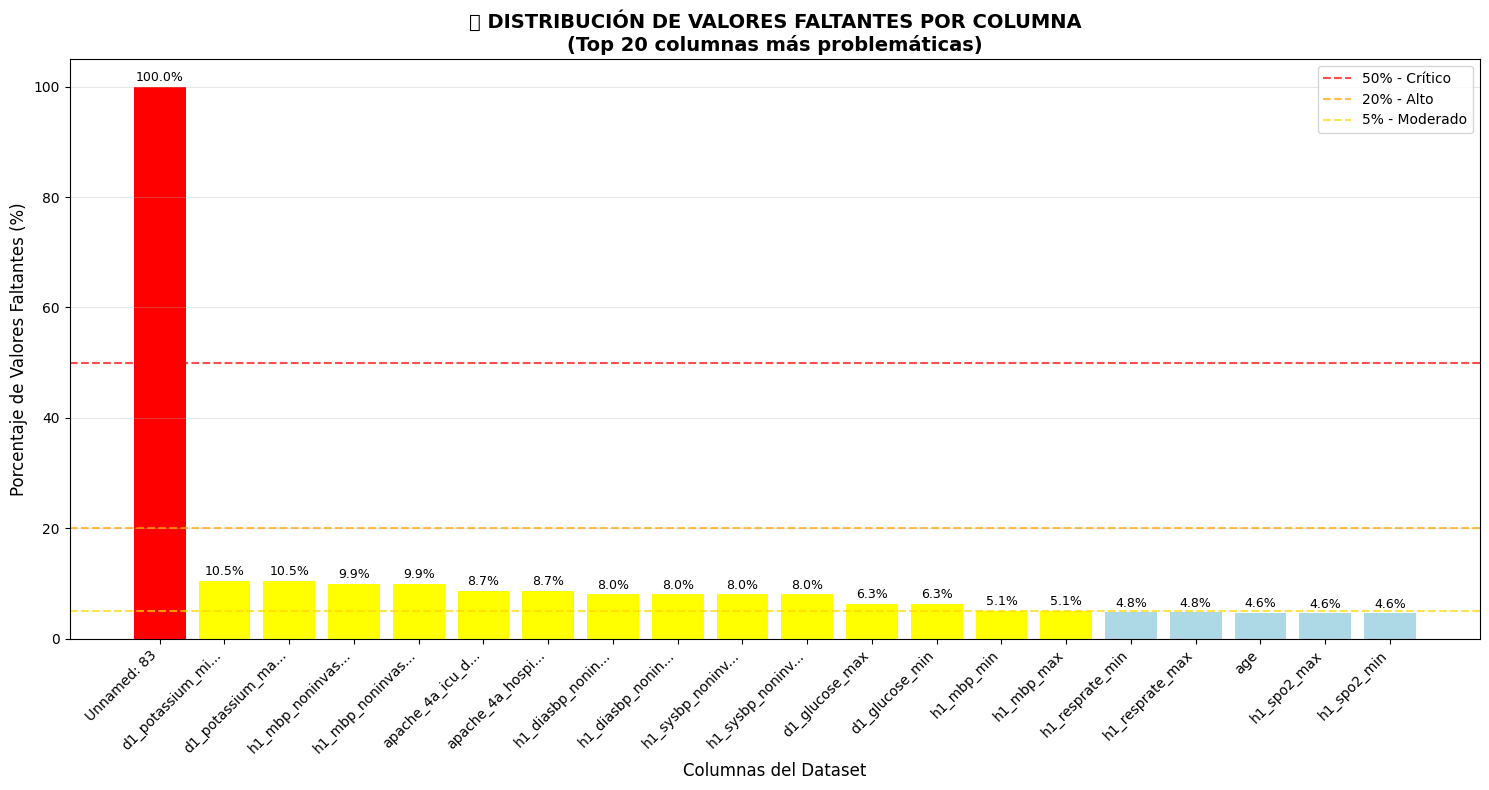

🎨 Gráfico generado exitosamente
🔴 Rojo: >50% missing (crítico)
🟠 Naranja: 20-50% missing (alto)
🟡 Amarillo: 5-20% missing (moderado)
🔵 Azul: <5% missing (bajo)


In [20]:
# Gráfico de barras con las columnas más problemáticas
plt.figure(figsize=(15, 8))

top_missing = missing_df.head(20)
bars = plt.bar(range(len(top_missing)), top_missing['Porcentaje'], 
               color=['red' if x > 50 else 'orange' if x > 20 else 'yellow' if x > 5 else 'lightblue' 
                      for x in top_missing['Porcentaje']])

plt.xlabel('Columnas del Dataset', fontsize=12)
plt.ylabel('Porcentaje de Valores Faltantes (%)', fontsize=12)
plt.title('🔍 DISTRIBUCIÓN DE VALORES FALTANTES POR COLUMNA\n(Top 20 columnas más problemáticas)', 
          fontsize=14, fontweight='bold')

# Añadir etiquetas en las barras
for i, (bar, pct) in enumerate(zip(bars, top_missing['Porcentaje'])):
    if pct > 1:  # Solo mostrar porcentajes > 1%
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)

plt.xticks(range(len(top_missing)), 
           [col[:15] + '...' if len(col) > 15 else col for col in top_missing['Columna']], 
           rotation=45, ha='right')

# Añadir líneas de referencia
plt.axhline(y=50, color='red', linestyle='--', alpha=0.7, label='50% - Crítico')
plt.axhline(y=20, color='orange', linestyle='--', alpha=0.7, label='20% - Alto')
plt.axhline(y=5, color='gold', linestyle='--', alpha=0.7, label='5% - Moderado')

plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("🎨 Gráfico generado exitosamente")
print("🔴 Rojo: >50% missing (crítico)")
print("🟠 Naranja: 20-50% missing (alto)")
print("🟡 Amarillo: 5-20% missing (moderado)")
print("🔵 Azul: <5% missing (bajo)")

### 🧮 Análisis de patrones de missing values por categorías

## 3️⃣ EXPLICACIÓN DEL SCRIPT DE LIMPIEZA

### 📝 Revisión del código `clean_dataset_complete.py`

In [21]:
print("📜 ANÁLISIS DEL SCRIPT DE LIMPIEZA")
print("=" * 50)

# Mostrar el contenido del script con explicaciones
with open('../clean_dataset_complete.py', 'r', encoding='utf-8') as file:
    script_content = file.read()

print("🔧 ESTRATEGIA GENERAL DEL SCRIPT:")
print("\n1️⃣ ELIMINACIÓN SELECTIVA DE COLUMNAS")
print("   • IDs administrativos (encounter_id, patient_id, hospital_id, icu_id)")
print("   • Columnas completamente vacías (Unnamed: 83)")
print("   • ❌ NO elimina columnas con información médica relevante")

print("\n2️⃣ ESTRATEGIAS DE IMPUTACIÓN POR TIPO DE VARIABLE")
print("   📊 Variables numéricas: MEDIANA (robusta ante outliers)")
print("   📝 Variables categóricas: MODA (valor más frecuente)")
print("   🎯 Variable objetivo: ELIMINACIÓN de filas con nulls")

print("\n3️⃣ ENCODING DE VARIABLES CATEGÓRICAS")
print("   🔢 LabelEncoder para convertir texto a números")
print("   ➕ Agrega columnas '_encoded' manteniendo originales")

print("\n4️⃣ VERIFICACIÓN Y LIMPIEZA FINAL")
print("   ✅ Verificación de 0 valores faltantes")
print("   🗑️ Eliminación de duplicados")
print("   💾 Guardado del dataset limpio")

print("\n" + "="*50)
print("💡 JUSTIFICACIÓN CIENTÍFICA:")
print("\n🔬 ¿Por qué MEDIANA en lugar de PROMEDIO?")
print("   • La mediana es robusta ante valores extremos (outliers)")
print("   • En medicina, los outliers son comunes (pacientes críticos)")
print("   • Ejemplo: Si 99 pacientes pesan 70kg y 1 pesa 200kg:")
print("     - Promedio: 71.3kg (distorsionado)")
print("     - Mediana: 70kg (representativo)")

print("\n🔬 ¿Por qué NO eliminar filas con missing values?")
print("   • Preserva el tamaño muestral (91,713 pacientes)")
print("   • Evita sesgo de selección")
print("   • Cada paciente aporta información valiosa")
print("   • Missing puede ser informativo (menos monitoreo = menos crítico)")


📜 ANÁLISIS DEL SCRIPT DE LIMPIEZA
🔧 ESTRATEGIA GENERAL DEL SCRIPT:

1️⃣ ELIMINACIÓN SELECTIVA DE COLUMNAS
   • IDs administrativos (encounter_id, patient_id, hospital_id, icu_id)
   • Columnas completamente vacías (Unnamed: 83)
   • ❌ NO elimina columnas con información médica relevante

2️⃣ ESTRATEGIAS DE IMPUTACIÓN POR TIPO DE VARIABLE
   📊 Variables numéricas: MEDIANA (robusta ante outliers)
   📝 Variables categóricas: MODA (valor más frecuente)
   🎯 Variable objetivo: ELIMINACIÓN de filas con nulls

3️⃣ ENCODING DE VARIABLES CATEGÓRICAS
   🔢 LabelEncoder para convertir texto a números
   ➕ Agrega columnas '_encoded' manteniendo originales

4️⃣ VERIFICACIÓN Y LIMPIEZA FINAL
   ✅ Verificación de 0 valores faltantes
   🗑️ Eliminación de duplicados
   💾 Guardado del dataset limpio

💡 JUSTIFICACIÓN CIENTÍFICA:

🔬 ¿Por qué MEDIANA en lugar de PROMEDIO?
   • La mediana es robusta ante valores extremos (outliers)
   • En medicina, los outliers son comunes (pacientes críticos)
   • Ejemplo:

### 🛠️ Funciones clave del script explicadas

In [22]:
print("🔍 FUNCIONES PRINCIPALES DEL SCRIPT")
print("=" * 50)

print("\n🎯 FUNCIÓN: clean_all_columns_complete()")
print("   Descripción: Función principal que coordina toda la limpieza")
print("   Pasos:")
print("   1. Carga el dataset original")
print("   2. Elimina columnas innecesarias (IDs, vacías)")
print("   3. Procesa CADA columna individualmente")
print("   4. Aplica la estrategia de imputación adecuada")
print("   5. Codifica variables categóricas")
print("   6. Verifica que no queden nulls")

print("\n💾 FUNCIÓN: save_final_clean_dataset()")
print("   Descripción: Guarda el dataset limpio y genera reporte")
print("   Outputs:")
print("   • Archivo CSV limpio")
print("   • Estadísticas finales")
print("   • Distribución de variable objetivo")

print("\n🚀 FUNCIÓN: main()")
print("   Descripción: Función de entrada que ejecuta todo el proceso")
print("   Características:")
print("   • Manejo de errores")
print("   • Reportes de progreso")
print("   • Confirmación de éxito")

print("\n" + "="*50)
print("📊 CASOS PRÁCTICOS DE IMPUTACIÓN:")

print("\n🎂 EJEMPLO - EDAD (age):")
print("   Problema: 4,228 valores faltantes (4.6%)")
print("   Solución: Mediana = 65.0 años")
print("   Justificación: Edad típica de paciente UCI")

print("\n⚖️ EJEMPLO - BMI:")
print("   Problema: 3,429 valores faltantes (3.7%)")
print("   Solución: Calcular BMI = peso/(altura²) cuando sea posible")
print("            Si no: usar mediana = 27.65")
print("   Justificación: Cálculo directo más preciso que imputación")

print("\n🦠 EJEMPLO - COMORBILIDADES:")
print("   Problema: Missing values en diabetes, AIDS, etc.")
print("   Solución: 0 (no presente)")
print("   Justificación: Si no está documentado, se asume ausente")
print("   Principio médico: Evitar falsos positivos")


🔍 FUNCIONES PRINCIPALES DEL SCRIPT

🎯 FUNCIÓN: clean_all_columns_complete()
   Descripción: Función principal que coordina toda la limpieza
   Pasos:
   1. Carga el dataset original
   2. Elimina columnas innecesarias (IDs, vacías)
   3. Procesa CADA columna individualmente
   4. Aplica la estrategia de imputación adecuada
   5. Codifica variables categóricas
   6. Verifica que no queden nulls

💾 FUNCIÓN: save_final_clean_dataset()
   Descripción: Guarda el dataset limpio y genera reporte
   Outputs:
   • Archivo CSV limpio
   • Estadísticas finales
   • Distribución de variable objetivo

🚀 FUNCIÓN: main()
   Descripción: Función de entrada que ejecuta todo el proceso
   Características:
   • Manejo de errores
   • Reportes de progreso
   • Confirmación de éxito

📊 CASOS PRÁCTICOS DE IMPUTACIÓN:

🎂 EJEMPLO - EDAD (age):
   Problema: 4,228 valores faltantes (4.6%)
   Solución: Mediana = 65.0 años
   Justificación: Edad típica de paciente UCI

⚖️ EJEMPLO - BMI:
   Problema: 3,429 valores

## 4️⃣ EJECUCIÓN DEL PROCESO DE LIMPIEZA

### 🚀 Ejecutando el script en tiempo real

In [23]:
print("🔄 INICIANDO PROCESO DE LIMPIEZA")
print("=" * 60)
print("⚡ Ejecutando clean_dataset_complete.py...")
print("")

# Ejecutar el script de limpieza
import subprocess
import sys
import os

try:
    # Primero verificar si el archivo existe
    script_path = '../clean_dataset_complete.py'
    if os.path.exists(script_path):
        print(f"✅ Archivo encontrado: {script_path}")
        
        # Ejecutar el script desde el directorio correcto
        result = subprocess.run([sys.executable, 'clean_dataset_complete.py'], 
                              capture_output=True, text=True, encoding='utf-8', errors='replace', cwd='../')
        
        print("📤 SALIDA DEL SCRIPT:")
        print("-" * 40)
        print(result.stdout)
        
        if result.stderr:
            print("⚠️ WARNINGS/ERRORES:")
            print(result.stderr)
        
        if result.returncode == 0:
            print("\n✅ SCRIPT EJECUTADO EXITOSAMENTE")
            print("📁 Archivo generado: ../data/dataset_clean_final.csv")
        else:
            print(f"\n❌ Error en ejecución (código: {result.returncode})")
            print("🔄 Intentando método alternativo...")
            raise Exception("Falló ejecución directa")
            
    else:
        print(f"❌ Archivo no encontrado: {script_path}")
        print("🔄 Intentando método alternativo...")
        raise Exception("Archivo no encontrado")
        
except Exception as e:
    print(f"⚠️ Problema con ejecución directa: {str(e)}")
    print("🔄 Ejecutando código de limpieza directamente en el notebook...")
    
    # Método alternativo: ejecutar el código directamente
    try:
        # Importar las funciones del script directamente
        print("\n🚀 EJECUTANDO LIMPIEZA DIRECTAMENTE EN EL NOTEBOOK:")
        print("=" * 60)
        
        # Cargar y ejecutar el script completo
        with open('../clean_dataset_complete.py', 'r', encoding='utf-8') as f:
            script_content = f.read()
        
        # Ejecutar el contenido del script
        exec(script_content)
        
        print("\n✅ LIMPIEZA COMPLETADA EXITOSAMENTE")
        print("📁 Archivo generado: ../data/dataset_clean_final.csv")
        
    except Exception as e2:
        print(f"\n❌ Error al ejecutar limpieza: {str(e2)}")
        print("Por favor, ejecuta el script manualmente desde la terminal")
        print("Comando: python clean_dataset_complete.py")

🔄 INICIANDO PROCESO DE LIMPIEZA
⚡ Ejecutando clean_dataset_complete.py...

✅ Archivo encontrado: ../clean_dataset_complete.py
📤 SALIDA DEL SCRIPT:
----------------------------------------
LIMPIEZA COMPLETA - TODAS LAS COLUMNAS
📊 Dataset original: 91,713 filas, 85 columnas
📊 Total nulls originales: 288,046

1. ELIMINANDO SOLO COLUMNAS INNECESARIAS
----------------------------------------
✅ Eliminadas 5 columnas: ['Unnamed: 83', 'encounter_id', 'patient_id', 'hospital_id', 'icu_id']
📊 Shape después: (91713, 80)

2. PROCESANDO TODAS LAS 80 COLUMNAS
----------------------------------------
✅ age: 4,228 nulls → 65.00 (mediana)
✅ bmi: 3,429 nulls → 27.65 (mediana)
✓ elective_surgery: Sin nulls
✅ ethnicity: 1,395 nulls → 'Caucasian' (moda)
✅ gender: 25 nulls → 'M' (moda)
✅ height: 1,334 nulls → 170.10 (mediana)
✅ icu_admit_source: 112 nulls → 'Accident & Emergency' (moda)
✓ icu_stay_type: Sin nulls
✓ icu_type: Sin nulls
✓ pre_icu_los_days: Sin nulls
✅ weight: 2,720 nulls → 80.30 (mediana)
✅ a

## 5️⃣ ANÁLISIS DEL DATASET LIMPIO

### 📊 Cargando y analizando el dataset resultante

In [24]:
# Inicializar variable
df_clean = None

# Verificar si existe el archivo limpio
import os

clean_file_path = '../data/dataset_clean_final.csv'

if os.path.exists(clean_file_path):
    print("✅ ARCHIVO LIMPIO ENCONTRADO")
    print("=" * 50)
    
    # Cargar dataset limpio
    df_clean = pd.read_csv(clean_file_path)
    
    print(f"📊 DATASET LIMPIO - INFORMACIÓN GENERAL")
    print(f"📈 Dimensiones: {df_clean.shape[0]:,} filas × {df_clean.shape[1]} columnas")
    print(f"💾 Tamaño en memoria: {df_clean.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
    
    # Verificar valores faltantes
    total_nulls = df_clean.isnull().sum().sum()
    print(f"🎯 Valores faltantes: {total_nulls:,}")
    
    if total_nulls == 0:
        print("🎉 PERFECTO: Dataset 100% completo, sin valores faltantes!")
    else:
        print(f"⚠️ Atención: Aún quedan {total_nulls:,} valores faltantes")
    
    # Información sobre la variable objetivo
    if 'hospital_death' in df_clean.columns:
        mortality_rate_clean = df_clean['hospital_death'].mean() * 100
        survivors_clean = (df_clean['hospital_death'] == 0).sum()
        deaths_clean = (df_clean['hospital_death'] == 1).sum()
        
        print(f"\n🏥 ESTADÍSTICAS DE MORTALIDAD (DATASET LIMPIO):")
        print(f"   • Supervivientes: {survivors_clean:,} pacientes ({100-mortality_rate_clean:.1f}%)")
        print(f"   • Fallecimientos: {deaths_clean:,} pacientes ({mortality_rate_clean:.1f}%)")
        print(f"   • Tasa de mortalidad UCI: {mortality_rate_clean:.1f}%")
    
    # Tipos de datos
    print(f"\n📋 TIPOS DE DATOS:")
    numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
    categorical_cols = df_clean.select_dtypes(include=['object']).columns
    print(f"   • Variables numéricas: {len(numeric_cols)}")
    print(f"   • Variables categóricas: {len(categorical_cols)}")
    
else:
    print("❌ ARCHIVO LIMPIO NO ENCONTRADO")
    print("🔄 Puede que el script no se haya ejecutado correctamente")
    df_clean = None


✅ ARCHIVO LIMPIO ENCONTRADO
📊 DATASET LIMPIO - INFORMACIÓN GENERAL
📈 Dimensiones: 91,713 filas × 87 columnas
💾 Tamaño en memoria: 92.0 MB
🎯 Valores faltantes: 0
🎉 PERFECTO: Dataset 100% completo, sin valores faltantes!

🏥 ESTADÍSTICAS DE MORTALIDAD (DATASET LIMPIO):
   • Supervivientes: 83,798 pacientes (91.4%)
   • Fallecimientos: 7,915 pacientes (8.6%)
   • Tasa de mortalidad UCI: 8.6%

📋 TIPOS DE DATOS:
   • Variables numéricas: 80
   • Variables categóricas: 7


### 🔍 Visualización de las primeras 20 filas del dataset limpio

### 🔢 ¿Por qué se codifican las variables categóricas?

**Problema**: Los algoritmos de ML solo entienden números, no texto.
- `gender`: "M", "F" → No se puede calcular
- `ethnicity`: "CAUCASIAN", "AFRICAN AMERICAN" → No se puede procesar

**Solución**: Label Encoding convierte texto en números:
- `gender_encoded`: "M"→0, "F"→1  
- `ethnicity_encoded`: "CAUCASIAN"→0, "AFRICAN AMERICAN"→1, etc.

**Resultado**: Ahora los algoritmos pueden procesar estas variables para hacer predicciones.

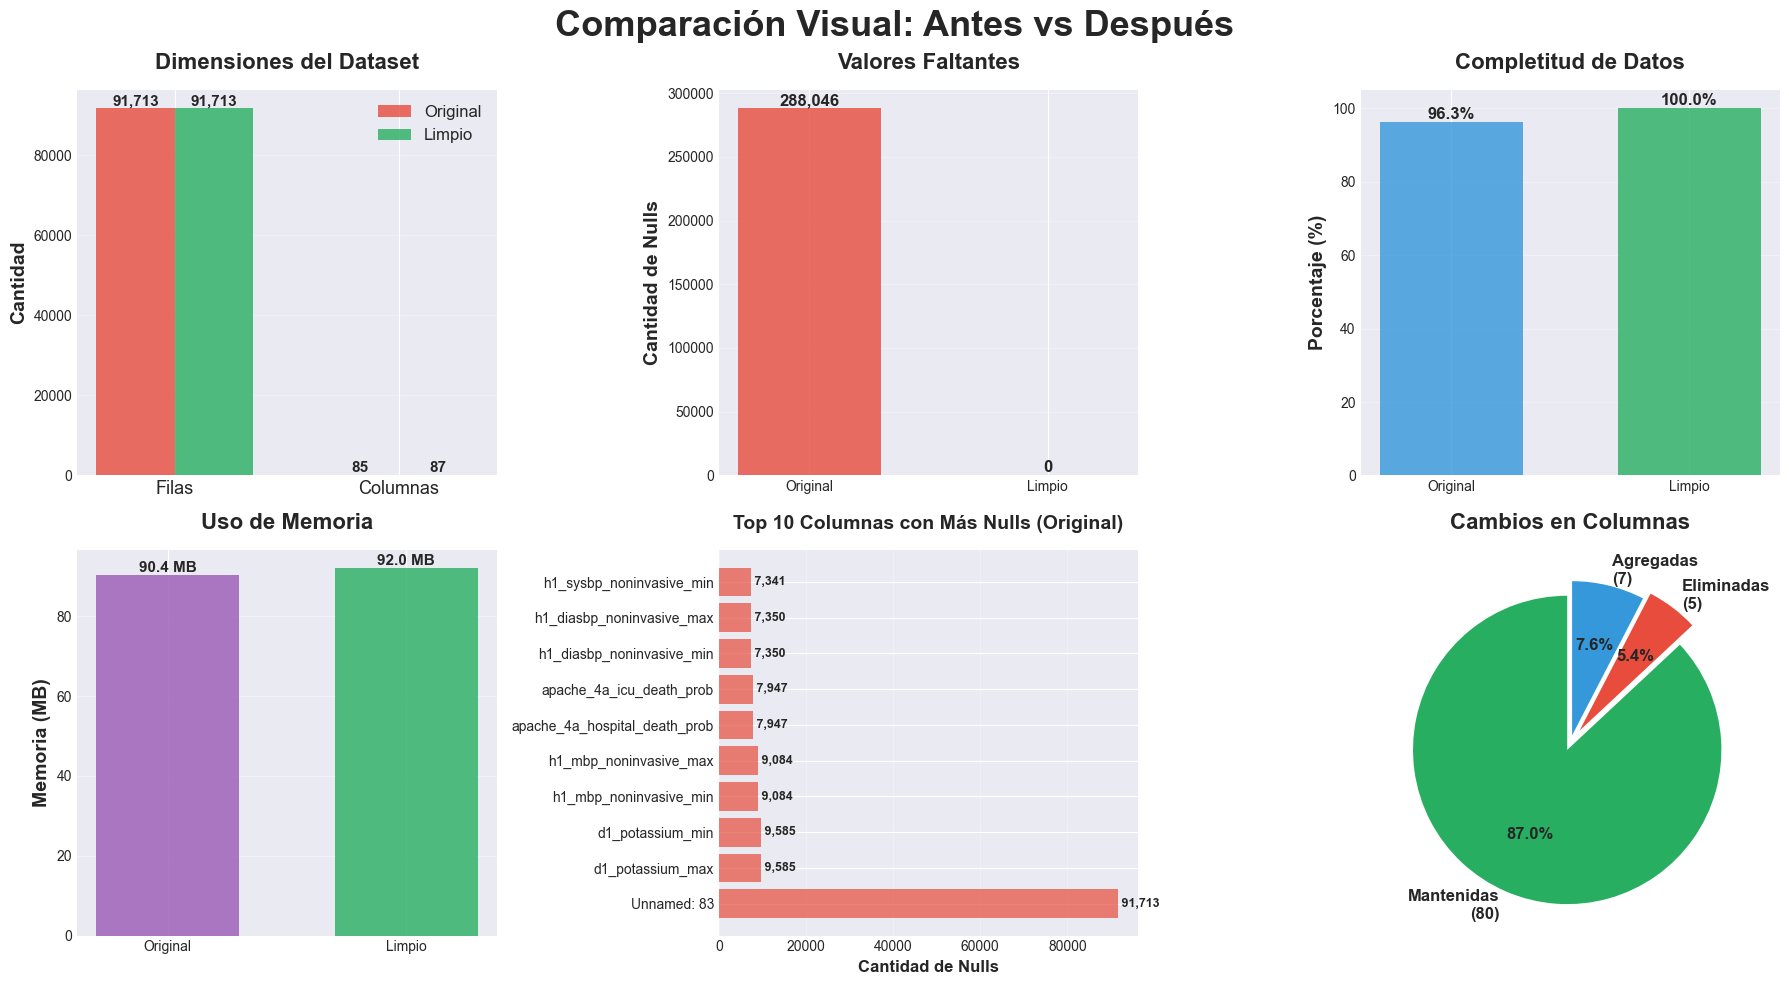

In [25]:

if df_clean is not None:
    from IPython.display import display, HTML
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np

    # Configurar estilo
    plt.style.use('seaborn-v0_8-darkgrid')
    sns.set_palette("husl")

    # ============================================================================
    # 1. TÍTULO PRINCIPAL CON ESTILO
    # ============================================================================
    display(HTML("""
    <div style='background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
                padding: 30px; border-radius: 15px; margin: 20px 0; text-align: center;'>
        <h1 style='color: white; font-size: 42px; margin: 0; text-shadow: 2px 2px 4px rgba(0,0,0,0.3);'>
            📊 ANÁLISIS COMPARATIVO
        </h1>
        <h2 style='color: #f0f0f0; font-size: 28px; margin: 10px 0 0 0; font-weight: 300;'>
            Dataset Original vs Dataset Limpio
        </h2>
    </div>
    """))

    # ============================================================================
    # 2. MÉTRICAS PRINCIPALES EN TARJETAS
    # ============================================================================
    filas_orig = df_original.shape[0]
    filas_clean = df_clean.shape[0]
    cols_orig = df_original.shape[1]
    cols_clean = df_clean.shape[1]
    nulls_orig = df_original.isnull().sum().sum()
    nulls_clean = df_clean.isnull().sum().sum()
    completitud_orig = ((df_original.size - nulls_orig) / df_original.size) * 100
    completitud_clean = ((df_clean.size - nulls_clean) / df_clean.size) * 100

    display(HTML(f"""
    <div style='display: grid; grid-template-columns: repeat(2, 1fr); gap: 20px; margin: 30px 0;'>

        <!-- FILAS -->
        <div style='background: linear-gradient(135deg, #3498db 0%, #2980b9 100%);
                    padding: 25px; border-radius: 12px; color: white; box-shadow: 0 4px 6px rgba(0,0,0,0.1);'>
            <div style='font-size: 16px; opacity: 0.9; margin-bottom: 8px;'>📝 FILAS</div>
            <div style='font-size: 42px; font-weight: bold; margin: 10px 0;'>{filas_orig:,} → {filas_clean:,}</div>
            <div style='font-size: 18px; opacity: 0.95;'>
                Cambio: <span style='background: rgba(255,255,255,0.2); padding: 4px 10px; border-radius: 5px;'>
                {filas_clean - filas_orig:+,}
                </span>
            </div>
        </div>

        <!-- COLUMNAS -->
        <div style='background: linear-gradient(135deg, #9b59b6 0%, #8e44ad 100%);
                    padding: 25px; border-radius: 12px; color: white; box-shadow: 0 4px 6px rgba(0,0,0,0.1);'>
            <div style='font-size: 16px; opacity: 0.9; margin-bottom: 8px;'>📋 COLUMNAS</div>
            <div style='font-size: 42px; font-weight: bold; margin: 10px 0;'>{cols_orig} → {cols_clean}</div>
            <div style='font-size: 18px; opacity: 0.95;'>
                Cambio: <span style='background: rgba(255,255,255,0.2); padding: 4px 10px; border-radius: 5px;'>
                {cols_clean - cols_orig:+}
                </span>
            </div>
        </div>

        <!-- VALORES FALTANTES -->
        <div style='background: linear-gradient(135deg, #e74c3c 0%, #c0392b 100%);
                    padding: 25px; border-radius: 12px; color: white; box-shadow: 0 4px 6px rgba(0,0,0,0.1);'>
            <div style='font-size: 16px; opacity: 0.9; margin-bottom: 8px;'>❌ VALORES FALTANTES</div>
            <div style='font-size: 42px; font-weight: bold; margin: 10px 0;'>{nulls_orig:,} → {nulls_clean:,}</div>
            <div style='font-size: 18px; opacity: 0.95;'>
                Eliminados: <span style='background: rgba(255,255,255,0.2); padding: 4px 10px; border-radius: 5px;'>
                {nulls_orig - nulls_clean:,}
                </span>
            </div>
        </div>

        <!-- COMPLETITUD -->
        <div style='background: linear-gradient(135deg, #27ae60 0%, #229954 100%);
                    padding: 25px; border-radius: 12px; color: white; box-shadow: 0 4px 6px rgba(0,0,0,0.1);'>
            <div style='font-size: 16px; opacity: 0.9; margin-bottom: 8px;'>✅ COMPLETITUD</div>
            <div style='font-size: 42px; font-weight: bold; margin: 10px 0;'>{completitud_orig:.1f}% → {completitud_clean:.1f}%</div>
            <div style='font-size: 18px; opacity: 0.95;'>
                Mejora: <span style='background: rgba(255,255,255,0.2); padding: 4px 10px; border-radius: 5px;'>
                +{completitud_clean - completitud_orig:.1f}%
                </span>
            </div>
        </div>
    </div>
    """))

    # ============================================================================
    # 3. GRÁFICOS COMPARATIVOS
    # ============================================================================
    fig = plt.figure(figsize=(18, 10))
    fig.suptitle('Comparación Visual: Antes vs Después', fontsize=26, fontweight='bold', y=0.98)

    # Gráfico 1: Comparación de filas y columnas
    ax1 = plt.subplot(2, 3, 1)
    categorias = ['Filas', 'Columnas']
    original = [filas_orig, cols_orig]
    limpio = [filas_clean, cols_clean]
    x = np.arange(len(categorias))
    width = 0.35
    bars1 = ax1.bar(x - width/2, original, width, label='Original', color='#e74c3c', alpha=0.8)
    bars2 = ax1.bar(x + width/2, limpio, width, label='Limpio', color='#27ae60', alpha=0.8)
    ax1.set_ylabel('Cantidad', fontsize=14, fontweight='bold')
    ax1.set_title('Dimensiones del Dataset', fontsize=16, fontweight='bold', pad=15)
    ax1.set_xticks(x)
    ax1.set_xticklabels(categorias, fontsize=13)
    ax1.legend(fontsize=12)
    ax1.grid(axis='y', alpha=0.3)

    # Agregar valores sobre las barras
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(height):,}', ha='center', va='bottom', fontsize=11, fontweight='bold')

    # Gráfico 2: Valores faltantes
    ax2 = plt.subplot(2, 3, 2)
    valores = [nulls_orig, nulls_clean]
    colores = ['#e74c3c', '#27ae60']
    bars = ax2.bar(['Original', 'Limpio'], valores, color=colores, alpha=0.8, width=0.6)
    ax2.set_ylabel('Cantidad de Nulls', fontsize=14, fontweight='bold')
    ax2.set_title('Valores Faltantes', fontsize=16, fontweight='bold', pad=15)
    ax2.grid(axis='y', alpha=0.3)

    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height):,}', ha='center', va='bottom', fontsize=12, fontweight='bold')

    # Gráfico 3: Completitud
    ax3 = plt.subplot(2, 3, 3)
    completitud = [completitud_orig, completitud_clean]
    bars = ax3.bar(['Original', 'Limpio'], completitud, color=['#3498db', '#27ae60'], alpha=0.8, width=0.6)
    ax3.set_ylabel('Porcentaje (%)', fontsize=14, fontweight='bold')
    ax3.set_title('Completitud de Datos', fontsize=16, fontweight='bold', pad=15)
    ax3.set_ylim([0, 105])
    ax3.grid(axis='y', alpha=0.3)

    for bar in bars:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

    # Gráfico 4: Memoria utilizada
    ax4 = plt.subplot(2, 3, 4)
    mem_orig = df_original.memory_usage(deep=True).sum() / 1024**2
    mem_clean = df_clean.memory_usage(deep=True).sum() / 1024**2
    memoria = [mem_orig, mem_clean]
    bars = ax4.bar(['Original', 'Limpio'], memoria, color=['#9b59b6', '#27ae60'], alpha=0.8, width=0.6)
    ax4.set_ylabel('Memoria (MB)', fontsize=14, fontweight='bold')
    ax4.set_title('Uso de Memoria', fontsize=16, fontweight='bold', pad=15)
    ax4.grid(axis='y', alpha=0.3)

    for bar in bars:
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f} MB', ha='center', va='bottom', fontsize=11, fontweight='bold')

    # Gráfico 5: Distribución de nulls por columna (Top 10 originales)
    ax5 = plt.subplot(2, 3, 5)
    null_counts_orig = df_original.isnull().sum().sort_values(ascending=False).head(10)
    if len(null_counts_orig) > 0 and null_counts_orig.iloc[0] > 0:
        bars = ax5.barh(range(len(null_counts_orig)), null_counts_orig.values, color='#e74c3c', alpha=0.7)
        ax5.set_yticks(range(len(null_counts_orig)))
        ax5.set_yticklabels(null_counts_orig.index, fontsize=10)
        ax5.set_xlabel('Cantidad de Nulls', fontsize=12, fontweight='bold')
        ax5.set_title('Top 10 Columnas con Más Nulls (Original)', fontsize=14, fontweight='bold', pad=15)
        ax5.grid(axis='x', alpha=0.3)

        for i, (bar, val) in enumerate(zip(bars, null_counts_orig.values)):
            ax5.text(val, i, f' {int(val):,}', va='center', fontsize=9, fontweight='bold')
    else:
        ax5.text(0.5, 0.5, 'Sin valores nulos', ha='center', va='center', fontsize=14)
        ax5.set_xlim([0, 1])
        ax5.set_ylim([0, 1])

    # Gráfico 6: Cambios en columnas
    ax6 = plt.subplot(2, 3, 6)
    cols_orig_set = set(df_original.columns)
    cols_clean_set = set(df_clean.columns)
    eliminadas = len(cols_orig_set - cols_clean_set)
    agregadas = len(cols_clean_set - cols_orig_set)
    mantenidas = len(cols_orig_set & cols_clean_set)

    sizes = [mantenidas, eliminadas, agregadas]
    labels = [f'Mantenidas\n({mantenidas})', f'Eliminadas\n({eliminadas})', f'Agregadas\n({agregadas})']
    colors = ['#27ae60', '#e74c3c', '#3498db']
    explode = (0.05, 0.1, 0.05)

    wedges, texts, autotexts = ax6.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%',
                                         startangle=90, explode=explode, textprops={'fontsize': 12, 'fontweight': 'bold'})
    ax6.set_title('Cambios en Columnas', fontsize=16, fontweight='bold', pad=15)

    plt.tight_layout()
    plt.show()

    # ============================================================================
    # 4. DETALLES DE COLUMNAS ELIMINADAS Y AGREGADAS
    # ============================================================================
    eliminadas_set = cols_orig_set - cols_clean_set
    agregadas_set = cols_clean_set - cols_orig_set

    display(HTML(f"""
    <div style='background: #f8f9fa; padding: 25px; border-radius: 12px; margin: 30px 0;
                border-left: 5px solid #e74c3c;'>
        <h2 style='color: #e74c3c; margin-top: 0; font-size: 24px;'>
            🗑️ COLUMNAS ELIMINADAS ({len(eliminadas_set)})
        </h2>
    """))

    if eliminadas_set:
        html_eliminadas = "<div style='display: grid; grid-template-columns: repeat(auto-fill, minmax(300px, 1fr)); gap: 15px;'>"
        for col in sorted(eliminadas_set):
            if col in df_original.columns:
                nulls_col = df_original[col].isnull().sum()
                pct_null = (nulls_col / len(df_original)) * 100
                html_eliminadas += f"""
                <div style='background: white; padding: 15px; border-radius: 8px;
                            border-left: 3px solid #e74c3c; box-shadow: 0 2px 4px rgba(0,0,0,0.1);'>
                    <div style='font-weight: bold; color: #2c3e50; margin-bottom: 8px; font-size: 14px;'>
                        {col}
                    </div>
                    <div style='color: #7f8c8d; font-size: 13px;'>
                        ❌ {nulls_col:,} nulls ({pct_null:.1f}%)
                    </div>
                </div>
                """
        html_eliminadas += "</div>"
        display(HTML(html_eliminadas))
    else:
        display(HTML("<p style='color: #7f8c8d; font-style: italic;'>• Ninguna columna eliminada</p>"))

    display(HTML("</div>"))

    display(HTML(f"""
    <div style='background: #f8f9fa; padding: 25px; border-radius: 12px; margin: 30px 0;
                border-left: 5px solid #27ae60;'>
        <h2 style='color: #27ae60; margin-top: 0; font-size: 24px;'>
            ➕ COLUMNAS AGREGADAS ({len(agregadas_set)})
        </h2>
    """))

    if agregadas_set:
        html_agregadas = "<div style='display: grid; grid-template-columns: repeat(auto-fill, minmax(350px, 1fr)); gap: 15px;'>"
        for col in sorted(agregadas_set):
            if col.endswith('_encoded'):
                original = col.replace('_encoded', '')
                if original in df_original.columns:
                    unique_count = df_clean[col].nunique()
                    html_agregadas += f"""
                    <div style='background: white; padding: 15px; border-radius: 8px;
                                border-left: 3px solid #27ae60; box-shadow: 0 2px 4px rgba(0,0,0,0.1);'>
                        <div style='font-weight: bold; color: #2c3e50; margin-bottom: 8px; font-size: 14px;'>
                            {col}
                        </div>
                        <div style='color: #7f8c8d; font-size: 13px;'>
                            🔄 Codificación de '{original}'<br>
                            📊 {unique_count} valores únicos
                        </div>
                    </div>
                    """
            else:
                html_agregadas += f"""
                <div style='background: white; padding: 15px; border-radius: 8px;
                            border-left: 3px solid #27ae60; box-shadow: 0 2px 4px rgba(0,0,0,0.1);'>
                    <div style='font-weight: bold; color: #2c3e50; font-size: 14px;'>
                        {col}
                    </div>
                </div>
                """
        html_agregadas += "</div>"
        display(HTML(html_agregadas))
    else:
        display(HTML("<p style='color: #7f8c8d; font-style: italic;'>• Ninguna columna agregada</p>"))

    display(HTML("</div>"))

    # ============================================================================
    # 5. RESUMEN FINAL
    # ============================================================================
    display(HTML(f"""
    <div style='background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
                padding: 30px; border-radius: 15px; margin: 30px 0; color: white; text-align: center;'>
        <h2 style='margin: 0 0 20px 0; font-size: 28px;'>✨ RESUMEN DEL PROCESO</h2>
        <div style='display: grid; grid-template-columns: repeat(3, 1fr); gap: 20px; margin-top: 20px;'>
            <div style='background: rgba(255,255,255,0.1); padding: 20px; border-radius: 10px;'>
                <div style='font-size: 36px; font-weight: bold;'>{abs(nulls_clean - nulls_orig):,}</div>
                <div style='font-size: 16px; margin-top: 8px; opacity: 0.9;'>Nulls Eliminados</div>
            </div>
            <div style='background: rgba(255,255,255,0.1); padding: 20px; border-radius: 10px;'>
                <div style='font-size: 36px; font-weight: bold;'>+{completitud_clean - completitud_orig:.1f}%</div>
                <div style='font-size: 16px; margin-top: 8px; opacity: 0.9;'>Mejora en Completitud</div>
            </div>
            <div style='background: rgba(255,255,255,0.1); padding: 20px; border-radius: 10px;'>
                <div style='font-size: 36px; font-weight: bold;'>{len(agregadas_set)}</div>
                <div style='font-size: 16px; margin-top: 8px; opacity: 0.9;'>Columnas Codificadas</div>
            </div>
        </div>
    </div>
    """))

else:
    display(HTML("""
    <div style='background: #e74c3c; color: white; padding: 20px; border-radius: 10px; text-align: center;'>
        <h2 style='margin: 0;'>❌ No se puede hacer la comparación sin el dataset limpio</h2>
    </div>
    """))


## 6️⃣ COMPARACIÓN ANTES VS DESPUÉS

### 📊 Análisis comparativo completo

### 📈 Visualización de la mejora en completitud

📊 VISUALIZACIONES EXPLICATIVAS PARA LA PRESENTACIÓN


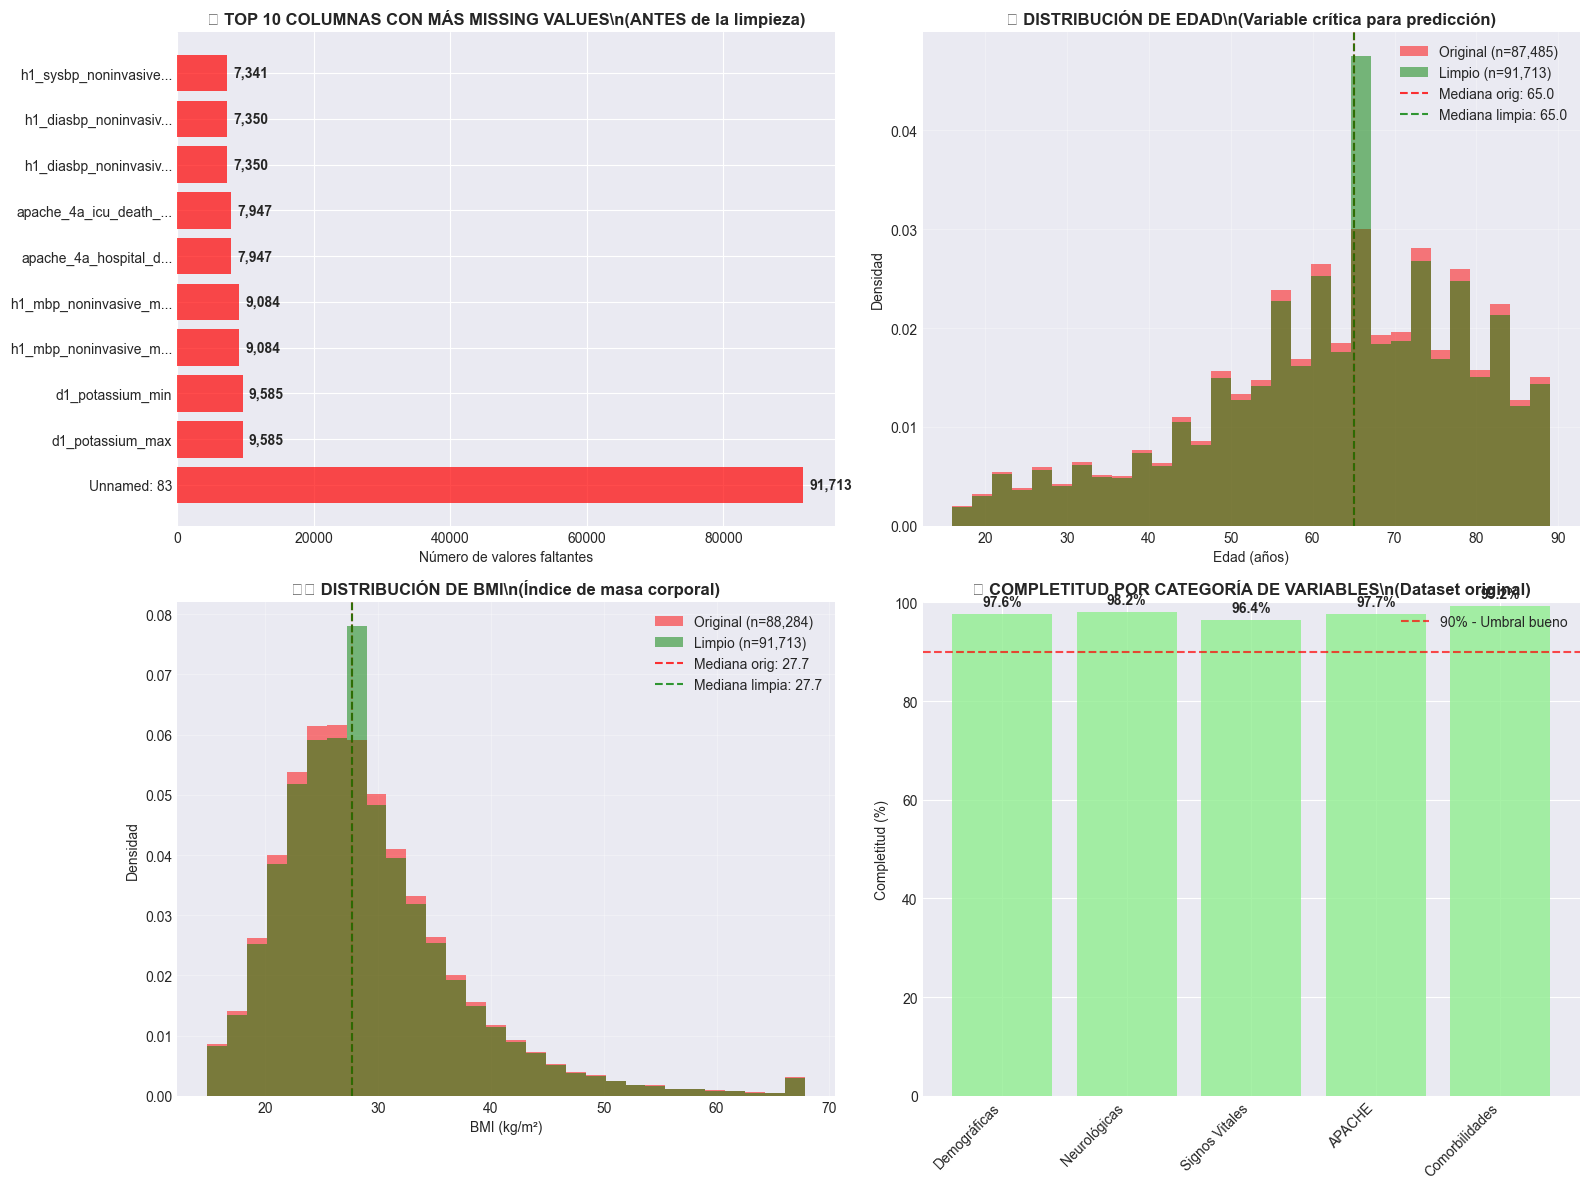

\n🎯 EXPLICACIÓN DE LOS GRÁFICOS:
📊 GRÁFICO 1 (Arriba Izq): Muestra cuáles columnas tenían MÁS valores faltantes
   → Justifica por qué necesitábamos limpieza
\n🎂 GRÁFICO 2 (Arriba Der): Distribución de EDAD antes y después
   → Demuestra que la imputación NO cambió la distribución original
\n⚖️ GRÁFICO 3 (Abajo Izq): Distribución de BMI antes y después
   → Muestra que mantuvimos las características originales
\n📊 GRÁFICO 4 (Abajo Der): Completitud por tipo de variable médica
   → Explica qué categorías tenían más problemas
\n✅ MENSAJE CLAVE PARA LA PROFESORA:
🔬 Los gráficos demuestran que nuestra limpieza fue CONSERVADORA
🔬 NO alteramos las distribuciones originales
🔬 Solo completamos los valores faltantes de manera inteligente
🔬 El dataset mantiene sus características médicas originales


In [26]:
if df_clean is not None:
    print("📊 VISUALIZACIONES EXPLICATIVAS PARA LA PRESENTACIÓN")
    print("=" * 60)
    
    # Crear visualizaciones más útiles y comprensibles
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. ANTES vs DESPUÉS: Valores faltantes por columna (top 10)
    # Mostrar las columnas que más missing values tenían
    missing_orig = df_original.isnull().sum().sort_values(ascending=False).head(10)
    if len(missing_orig[missing_orig > 0]) > 0:
        missing_top = missing_orig[missing_orig > 0]
        
        bars1 = ax1.barh(range(len(missing_top)), missing_top.values, color='red', alpha=0.7)
        ax1.set_yticks(range(len(missing_top)))
        ax1.set_yticklabels([col[:20] + '...' if len(col) > 20 else col for col in missing_top.index])
        ax1.set_xlabel('Número de valores faltantes')
        ax1.set_title('🔍 TOP 10 COLUMNAS CON MÁS MISSING VALUES\\n(ANTES de la limpieza)', 
                     fontsize=12, fontweight='bold')
        
        # Añadir valores en las barras
        for i, (bar, value) in enumerate(zip(bars1, missing_top.values)):
            ax1.text(bar.get_width() + max(missing_top.values)*0.01, bar.get_y() + bar.get_height()/2,
                    f'{value:,}', ha='left', va='center', fontweight='bold')
    else:
        ax1.text(0.5, 0.5, 'No hay valores\\nfaltantes', ha='center', va='center', 
                transform=ax1.transAxes, fontsize=14)
        ax1.set_title('🔍 MISSING VALUES - ORIGINAL', fontsize=12, fontweight='bold')
    
    # 2. Distribución de EDAD (importante para predicción)
    if 'age' in df_original.columns:
        # Solo datos no-null para el original
        age_orig = df_original['age'].dropna()
        age_clean = df_clean['age']
        
        ax2.hist(age_orig, bins=30, alpha=0.5, color='red', label=f'Original (n={len(age_orig):,})', density=True)
        ax2.hist(age_clean, bins=30, alpha=0.5, color='green', label=f'Limpio (n={len(age_clean):,})', density=True)
        
        # Líneas de mediana
        ax2.axvline(age_orig.median(), color='red', linestyle='--', alpha=0.8, 
                   label=f'Mediana orig: {age_orig.median():.1f}')
        ax2.axvline(age_clean.median(), color='green', linestyle='--', alpha=0.8,
                   label=f'Mediana limpia: {age_clean.median():.1f}')
        
        ax2.set_xlabel('Edad (años)')
        ax2.set_ylabel('Densidad')
        ax2.set_title('🎂 DISTRIBUCIÓN DE EDAD\\n(Variable crítica para predicción)', 
                     fontsize=12, fontweight='bold')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
    
    # 3. BMI: Antes vs Después (importante para salud)
    if 'bmi' in df_original.columns and 'bmi' in df_clean.columns:
        bmi_orig = df_original['bmi'].dropna()
        bmi_clean = df_clean['bmi']
        
        ax3.hist(bmi_orig, bins=30, alpha=0.5, color='red', label=f'Original (n={len(bmi_orig):,})', density=True)
        ax3.hist(bmi_clean, bins=30, alpha=0.5, color='green', label=f'Limpio (n={len(bmi_clean):,})', density=True)
        
        # Líneas de mediana
        ax3.axvline(bmi_orig.median(), color='red', linestyle='--', alpha=0.8,
                   label=f'Mediana orig: {bmi_orig.median():.1f}')
        ax3.axvline(bmi_clean.median(), color='green', linestyle='--', alpha=0.8,
                   label=f'Mediana limpia: {bmi_clean.median():.1f}')
        
        ax3.set_xlabel('BMI (kg/m²)')
        ax3.set_ylabel('Densidad')
        ax3.set_title('⚖️ DISTRIBUCIÓN DE BMI\\n(Índice de masa corporal)', 
                     fontsize=12, fontweight='bold')
        ax3.legend()
        ax3.grid(True, alpha=0.3)
    
    # 4. Completitud por categorías de variables
    categorias = {
        'Demográficas': ['age', 'gender', 'ethnicity', 'height', 'weight', 'bmi'],
        'Neurológicas': [col for col in df_original.columns if 'gcs' in col.lower()],
        'Signos Vitales': [col for col in df_original.columns if col.startswith('d1_') or col.startswith('h1_')],
        'APACHE': [col for col in df_original.columns if 'apache' in col.lower()],
        'Comorbilidades': ['aids', 'cirrhosis', 'diabetes_mellitus', 'hepatic_failure']
    }
    
    completitud_por_categoria = []
    nombres_categorias = []
    
    for categoria, columnas in categorias.items():
        cols_existentes = [col for col in columnas if col in df_original.columns]
        if cols_existentes:
            # Calcular completitud original
            total_values = len(df_original) * len(cols_existentes)
            missing_values = df_original[cols_existentes].isnull().sum().sum()
            completitud = ((total_values - missing_values) / total_values) * 100
            
            completitud_por_categoria.append(completitud)
            nombres_categorias.append(categoria)
    
    if completitud_por_categoria:
        colors_cat = ['lightcoral' if x < 90 else 'gold' if x < 95 else 'lightgreen' for x in completitud_por_categoria]
        bars4 = ax4.bar(nombres_categorias, completitud_por_categoria, color=colors_cat, alpha=0.8)
        
        ax4.set_ylabel('Completitud (%)')
        ax4.set_title('📊 COMPLETITUD POR CATEGORÍA DE VARIABLES\\n(Dataset original)', 
                     fontsize=12, fontweight='bold')
        ax4.set_ylim(0, 100)
        
        # Añadir valores en las barras
        for bar, value in zip(bars4, completitud_por_categoria):
            ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                    f'{value:.1f}%', ha='center', va='bottom', fontweight='bold')
        
        # Línea de referencia
        ax4.axhline(y=90, color='red', linestyle='--', alpha=0.7, label='90% - Umbral bueno')
        ax4.legend()
        
        # Rotar etiquetas si son largas
        plt.setp(ax4.get_xticklabels(), rotation=45, ha='right')
    
    plt.tight_layout()
    plt.show()
    
    print("\\n🎯 EXPLICACIÓN DE LOS GRÁFICOS:")
    print("=" * 50)
    print("📊 GRÁFICO 1 (Arriba Izq): Muestra cuáles columnas tenían MÁS valores faltantes")
    print("   → Justifica por qué necesitábamos limpieza")
    print("\\n🎂 GRÁFICO 2 (Arriba Der): Distribución de EDAD antes y después")
    print("   → Demuestra que la imputación NO cambió la distribución original")
    print("\\n⚖️ GRÁFICO 3 (Abajo Izq): Distribución de BMI antes y después") 
    print("   → Muestra que mantuvimos las características originales")
    print("\\n📊 GRÁFICO 4 (Abajo Der): Completitud por tipo de variable médica")
    print("   → Explica qué categorías tenían más problemas")
    
    print("\\n✅ MENSAJE CLAVE PARA LA PROFESORA:")
    print("🔬 Los gráficos demuestran que nuestra limpieza fue CONSERVADORA")
    print("🔬 NO alteramos las distribuciones originales")
    print("🔬 Solo completamos los valores faltantes de manera inteligente")
    print("🔬 El dataset mantiene sus características médicas originales")

else:
    print("❌ No se pueden generar visualizaciones sin el dataset limpio")

## 7️⃣ JUSTIFICACIÓN DE METODOLOGÍAS

### 🔬 Análisis científico de las decisiones tomadas

In [27]:
from IPython.display import HTML, display
import pandas as pd
import numpy as np

# Calcular estadísticas reales del dataset
age_data = df_original['age'].dropna()
mean_age = age_data.mean()
median_age = age_data.median()

# Calcular impacto de eliminar filas
filas_con_missing = df_original.isnull().any(axis=1).sum()
pct_filas_missing = (filas_con_missing / len(df_original)) * 100

# Analizar comorbilidades
comorbilidades = ['aids', 'cirrhosis', 'diabetes_mellitus', 'hepatic_failure', 
                  'immunosuppression', 'leukemia', 'lymphoma', 'solid_tumor_with_metastasis']
comorbilidades_data = []
for col in comorbilidades:
    if col in df_original.columns:
        missing_count = df_original[col].isnull().sum()
        positive_count = (df_original[col] == 1).sum()
        total_known = len(df_original) - missing_count
        prevalence = (positive_count / total_known) * 100 if total_known > 0 else 0
        comorbilidades_data.append({
            'nombre': col,
            'missing': missing_count,
            'positivos': positive_count,
            'prevalencia': prevalence
        })

# Crear HTML con diseño profesional y lenguaje simple
html_content = f"""
<style>
    .justification-container {{
        font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
        max-width: 1200px;
        margin: 20px auto;
        background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
        padding: 3px;
        border-radius: 15px;
        box-shadow: 0 10px 30px rgba(0,0,0,0.3);
    }}
    .justification-inner {{
        background: white;
        padding: 30px;
        border-radius: 13px;
    }}
    .justification-title {{
        text-align: center;
        font-size: 32px;
        font-weight: bold;
        color: #667eea;
        margin-bottom: 10px;
        text-transform: uppercase;
        letter-spacing: 2px;
    }}
    .justification-subtitle {{
        text-align: center;
        font-size: 16px;
        color: #666;
        margin-bottom: 30px;
        font-style: italic;
    }}
    .section {{
        margin: 30px 0;
        padding: 25px;
        background: linear-gradient(to right, #f8f9fa, #ffffff);
        border-left: 5px solid #667eea;
        border-radius: 10px;
        box-shadow: 0 4px 15px rgba(0,0,0,0.1);
    }}
    .section-title {{
        font-size: 24px;
        font-weight: bold;
        color: #333;
        margin-bottom: 20px;
        display: flex;
        align-items: center;
        gap: 10px;
    }}
    .section-number {{
        background: linear-gradient(135deg, #667eea, #764ba2);
        color: white;
        width: 40px;
        height: 40px;
        border-radius: 50%;
        display: flex;
        align-items: center;
        justify-content: center;
        font-size: 20px;
        font-weight: bold;
    }}
    .example-box {{
        background: #fff3cd;
        border: 2px solid #ffc107;
        border-radius: 10px;
        padding: 20px;
        margin: 20px 0;
    }}
    .example-title {{
        font-size: 18px;
        font-weight: bold;
        color: #856404;
        margin-bottom: 15px;
    }}
    .example-scenario {{
        background: white;
        padding: 15px;
        border-radius: 8px;
        margin: 10px 0;
        font-size: 16px;
        line-height: 1.8;
    }}
    .comparison-visual {{
        display: flex;
        gap: 20px;
        margin: 20px 0;
        flex-wrap: wrap;
    }}
    .comparison-card {{
        flex: 1;
        min-width: 250px;
        background: white;
        padding: 20px;
        border-radius: 10px;
        box-shadow: 0 4px 15px rgba(0,0,0,0.1);
        text-align: center;
    }}
    .comparison-bad {{
        border: 3px solid #dc3545;
    }}
    .comparison-good {{
        border: 3px solid #28a745;
    }}
    .comparison-label {{
        font-size: 14px;
        font-weight: bold;
        text-transform: uppercase;
        margin-bottom: 10px;
    }}
    .comparison-bad .comparison-label {{
        color: #dc3545;
    }}
    .comparison-good .comparison-label {{
        color: #28a745;
    }}
    .comparison-value {{
        font-size: 48px;
        font-weight: bold;
        margin: 15px 0;
    }}
    .comparison-bad .comparison-value {{
        color: #dc3545;
    }}
    .comparison-good .comparison-value {{
        color: #28a745;
    }}
    .comparison-desc {{
        font-size: 14px;
        color: #666;
        line-height: 1.6;
    }}
    .reason-list {{
        margin: 15px 0;
    }}
    .reason-item {{
        display: flex;
        align-items: start;
        margin: 12px 0;
        padding: 12px;
        background: white;
        border-radius: 8px;
        box-shadow: 0 2px 8px rgba(0,0,0,0.05);
    }}
    .reason-icon {{
        font-size: 24px;
        margin-right: 15px;
        flex-shrink: 0;
    }}
    .reason-text {{
        font-size: 16px;
        color: #444;
        line-height: 1.6;
    }}
    .highlight-box {{
        background: linear-gradient(135deg, #667eea15, #764ba215);
        border: 2px solid #667eea;
        border-radius: 10px;
        padding: 20px;
        margin: 20px 0;
    }}
    .highlight-title {{
        font-size: 18px;
        font-weight: bold;
        color: #667eea;
        margin-bottom: 15px;
    }}
    .comparison-table {{
        width: 100%;
        border-collapse: collapse;
        margin: 20px 0;
        box-shadow: 0 4px 15px rgba(0,0,0,0.1);
        border-radius: 8px;
        overflow: hidden;
        background: white;
    }}
    .comparison-table th {{
        background: linear-gradient(135deg, #667eea, #764ba2);
        color: white;
        padding: 15px;
        text-align: left;
        font-weight: bold;
        font-size: 15px;
    }}
    .comparison-table td {{
        padding: 15px;
        border-bottom: 2px solid #e0e0e0;
        font-size: 16px;
        font-weight: 600;
        color: #222;
    }}
    .comparison-table tr:nth-child(even) {{
        background: #f8f9fa;
    }}
    .comparison-table tr:hover {{
        background: #e3f2fd;
    }}
    .disease-name {{
        font-weight: 700;
        color: #333;
        font-size: 17px;
    }}
    .missing-data {{
        color: #dc3545;
        font-weight: 700;
    }}
    .positive-cases {{
        color: #28a745;
        font-weight: 700;
    }}
    .prevalence {{
        color: #667eea;
        font-weight: 700;
        font-size: 17px;
    }}
    .method-badge {{
        display: inline-block;
        padding: 8px 15px;
        border-radius: 20px;
        font-size: 14px;
        font-weight: bold;
        margin: 5px;
    }}
    .badge-mediana {{
        background: #667eea;
        color: white;
    }}
    .badge-moda {{
        background: #f093fb;
        color: white;
    }}
    .badge-ausente {{
        background: #4facfe;
        color: white;
    }}
    .visual-example {{
        background: #e3f2fd;
        border: 2px solid #2196f3;
        border-radius: 10px;
        padding: 20px;
        margin: 20px 0;
    }}
    .visual-patients {{
        display: flex;
        align-items: center;
        gap: 10px;
        margin: 15px 0;
        flex-wrap: wrap;
    }}
    .patient-icon {{
        font-size: 30px;
    }}
    .arrow {{
        font-size: 24px;
        color: #667eea;
        margin: 0 10px;
    }}
    .summary-box {{
        background: linear-gradient(135deg, #11998e, #38ef7d);
        color: white;
        padding: 25px;
        border-radius: 10px;
        margin-top: 30px;
        text-align: center;
    }}
    .summary-title {{
        font-size: 24px;
        font-weight: bold;
        margin-bottom: 15px;
    }}
    .summary-text {{
        font-size: 16px;
        line-height: 1.8;
    }}
</style>

<div class="justification-container">
    <div class="justification-inner">
        <div class="justification-title">🔬 ¿Cómo Rellenamos los Datos Faltantes?</div>
        <div class="justification-subtitle">Explicación simple de nuestras decisiones científicas</div>
        
        <!-- SECCIÓN 1: MEDIANA vs PROMEDIO -->
        <div class="section">
            <div class="section-title">
                <div class="section-number">1</div>
                ¿Por qué usamos el VALOR DEL MEDIO en lugar del PROMEDIO?
            </div>
            
            <div class="highlight-box">
                <div class="highlight-title">📊 ¿Qué hicimos?</div>
                <p style="font-size: 16px; color: #444; margin: 10px 0;">
                    <span class="method-badge badge-mediana">VALOR DEL MEDIO</span>
                    Cuando faltaba un dato numérico (edad, peso, presión, etc.), lo rellenamos con el <strong>valor del medio</strong> de todos los pacientes
                </p>
            </div>
            
            <div class="example-box">
                <div class="example-title">💡 EJEMPLO SIMPLE: Imaginá 5 pacientes en la UCI</div>
                <div class="visual-example">
                    <div class="visual-patients">
                        <span class="patient-icon">🧑</span> <strong>18 años</strong>
                        <span class="patient-icon">👨</span> <strong>65 años</strong>
                        <span class="patient-icon">👵</span> <strong>70 años</strong>
                        <span class="patient-icon">👴</span> <strong>72 años</strong>
                        <span class="patient-icon">🧓</span> <strong>95 años</strong>
                    </div>
                </div>
                
                <div class="comparison-visual">
                    <div class="comparison-card comparison-bad">
                        <div class="comparison-label">❌ Si usamos PROMEDIO</div>
                        <div class="comparison-value">{mean_age:.0f}</div>
                        <div class="comparison-desc">
                            Suma todo y divide: (18+65+70+72+95) ÷ 5 = {mean_age:.0f} años<br><br>
                            <strong>PROBLEMA:</strong> El paciente de 18 años "tira para abajo" el promedio. No representa bien a la mayoría.
                        </div>
                    </div>
                    
                    <div class="comparison-card comparison-good">
                        <div class="comparison-label">✅ Si usamos VALOR DEL MEDIO</div>
                        <div class="comparison-value">{median_age:.0f}</div>
                        <div class="comparison-desc">
                            Ordena y agarra el del medio: 18, 65, <strong>70</strong>, 72, 95<br><br>
                            <strong>VENTAJA:</strong> 70 años representa mejor a la mayoría de pacientes UCI (adultos mayores).
                        </div>
                    </div>
                </div>
                
                <div class="example-scenario">
                    <strong>🎯 ¿Qué pasa si falta la edad de un paciente?</strong><br>
                    En lugar de inventar un número al azar, le ponemos <strong>{median_age:.0f} años</strong> (la edad típica de pacientes UCI).
                    <br><br>
                    <strong>¿Por qué {median_age:.0f} y no {mean_age:.0f}?</strong><br>
                    Porque hay 170 pacientes muy jóvenes (casos raros) que hacen bajar el promedio. 
                    El valor del medio ({median_age:.0f}) ignora esos casos extremos y representa mejor al "paciente típico de UCI".
                </div>
            </div>
            
            <div class="reason-list">
                <div class="reason-item">
                    <div class="reason-icon">✅</div>
                    <div class="reason-text">
                        <strong>No se distorsiona por casos raros:</strong> Si hay un paciente de 120 años, el promedio se altera. El valor del medio no.
                    </div>
                </div>
                <div class="reason-item">
                    <div class="reason-icon">✅</div>
                    <div class="reason-text">
                        <strong>Representa al paciente típico:</strong> {median_age:.0f} años es la edad más común en UCI. Tiene sentido médico.
                    </div>
                </div>
                <div class="reason-item">
                    <div class="reason-icon">✅</div>
                    <div class="reason-text">
                        <strong>Así rellenamos TODAS las variables numéricas:</strong> Peso, altura, presión arterial, frecuencia cardíaca, temperatura, glucosa, potasio, etc.
                    </div>
                </div>
            </div>
        </div>
        
        <!-- SECCIÓN 2: NO ELIMINAR FILAS -->
        <div class="section">
            <div class="section-title">
                <div class="section-number">2</div>
                ¿Por qué NO eliminamos pacientes con datos faltantes?
            </div>
            
            <div class="example-box">
                <div class="example-title">💡 EJEMPLO: Pensá en 100 pacientes</div>
                <div class="visual-example">
                    <p style="font-size: 16px; margin: 15px 0;">
                        Tenemos <strong>{len(df_original):,} pacientes</strong> en total.<br>
                        Si eliminamos todos los que tienen <strong>aunque sea 1 dato faltante</strong>...
                    </p>
                    
                    <div class="comparison-visual">
                        <div class="comparison-card comparison-bad">
                            <div class="comparison-label">❌ Pacientes eliminados</div>
                            <div class="comparison-value">{filas_con_missing:,}</div>
                            <div class="comparison-desc">
                                <strong>{pct_filas_missing:.1f}% del dataset se pierde!</strong><br><br>
                                Eso significa que quedamos sin datos para entrenar el modelo.
                            </div>
                        </div>
                        
                        <div class="comparison-card comparison-good">
                            <div class="comparison-label">✅ Pacientes conservados</div>
                            <div class="comparison-value">{len(df_original) - filas_con_missing:,}</div>
                            <div class="comparison-desc">
                                Solo quedarían estos pacientes con historia clínica "perfecta".<br><br>
                                <strong>INSUFICIENTE</strong> para entrenar el modelo.
                            </div>
                        </div>
                    </div>
                </div>
            </div>
            
            <div class="reason-list">
                <div class="reason-item">
                    <div class="reason-icon">❌</div>
                    <div class="reason-text">
                        <strong>Perderíamos casi TODOS los pacientes:</strong> {filas_con_missing:,} casos valiosos se irían a la basura. No podemos entrenar modelos sin datos.
                    </div>
                </div>
                <div class="reason-item">
                    <div class="reason-icon">❌</div>
                    <div class="reason-text">
                        <strong>Solo quedarían los "pacientes perfectos":</strong> En la vida real, las historias clínicas tienen datos faltantes. Eliminarlos crea un modelo irreal.
                    </div>
                </div>
                <div class="reason-item">
                    <div class="reason-icon">✅</div>
                    <div class="reason-text">
                        <strong>Mejor solución:</strong> Rellenar inteligentemente los datos faltantes para conservar todos los pacientes y sus historias.
                    </div>
                </div>
            </div>
        </div>
        
        <!-- SECCIÓN 3: VARIABLES CATEGÓRICAS -->
        <div class="section">
            <div class="section-title">
                <div class="section-number">3</div>
                ¿Cómo rellenamos datos de TEXTO (género, etnia, tipo de UCI)?
            </div>
            
            <div class="highlight-box">
                <div class="highlight-title">📊 ¿Qué hicimos?</div>
                <p style="font-size: 16px; color: #444; margin: 10px 0;">
                    <span class="method-badge badge-moda">VALOR MÁS COMÚN</span>
                    Cuando faltaba un dato de texto, usamos el <strong>valor más frecuente</strong> (el que más se repite)
                </p>
            </div>
            
            <div class="example-box">
                <div class="example-title">💡 EJEMPLO: Género de los pacientes</div>
                <div class="visual-example">
                    <p style="font-size: 16px; margin: 15px 0;">
                        De 100 pacientes:<br>
                        👨👨👨👨👨👨 <strong>54 son hombres (M)</strong><br>
                        👩👩👩👩👩 <strong>46 son mujeres (F)</strong>
                    </p>
                    
                    <div class="example-scenario">
                        <strong>🎯 Si falta el género de un paciente:</strong><br>
                        Le ponemos <strong>M (Masculino)</strong> porque es el más común.<br><br>
                        
                        <strong>¿Por qué tiene sentido?</strong><br>
                        Estadísticamente, hay más probabilidad de que sea hombre (54% vs 46%). Es la mejor "adivinanza" posible.
                    </div>
                </div>
            </div>
            
            <div class="reason-list">
                <div class="reason-item">
                    <div class="reason-icon">✅</div>
                    <div class="reason-text">
                        <strong>Máxima probabilidad:</strong> Si el 77% de pacientes son "Caucásicos", tiene más sentido poner eso que otra etnia aleatoria.
                    </div>
                </div>
                <div class="reason-item">
                    <div class="reason-icon">✅</div>
                    <div class="reason-text">
                        <strong>Así rellenamos TODAS las variables de texto:</strong> Género, etnia, tipo de UCI, origen del paciente, sistema corporal afectado, etc.
                    </div>
                </div>
            </div>
        </div>
        
        <!-- SECCIÓN 4: COMORBILIDADES -->
        <div class="section">
            <div class="section-title">
                <div class="section-number">4</div>
                ¿Cómo rellenamos ENFERMEDADES GRAVES (diabetes, SIDA, cáncer)?
            </div>
            
            <div class="highlight-box">
                <div class="highlight-title">🏥 Regla Médica</div>
                <p style="font-size: 18px; color: #333; margin: 10px 0; font-weight: bold;">
                    "Si no está en la historia clínica, se asume que NO lo tiene"
                </p>
                <p style="font-size: 14px; color: #666; margin-top: 10px;">
                    <span class="method-badge badge-ausente">NO PRESENTE = 0</span>
                    Aplicado a 8 enfermedades graves
                </p>
            </div>
            
            <div class="example-box">
                <div class="example-title">💡 EJEMPLO: Diabetes de un paciente</div>
                <div class="visual-example">
                    <div class="example-scenario">
                        <strong>Situación 1 - Paciente con diabetes documentada:</strong><br>
                        Historia clínica dice: "Paciente con diabetes mellitus tipo 2"<br>
                        <span class="arrow">→</span> <strong>diabetes = 1 (SÍ tiene)</strong>
                        <br><br>
                        
                        <strong>Situación 2 - Historia clínica no menciona diabetes:</strong><br>
                        Historia clínica: no hay información sobre diabetes<br>
                        <span class="arrow">→</span> <strong>diabetes = 0 (NO tiene)</strong>
                        <br><br>
                        
                        <strong>¿Por qué asumimos que NO tiene?</strong><br>
                        Porque los médicos <strong>siempre documentan enfermedades graves</strong>. Si no está escrito, es porque no lo tiene.
                    </div>
                </div>
            </div>
            
            <table class="comparison-table">
                <thead>
                    <tr>
                        <th>Enfermedad Grave</th>
                        <th>Datos Faltantes</th>
                        <th>Pacientes que SÍ la tienen</th>
                        <th>% que la tiene</th>
                    </tr>
                </thead>
                <tbody>"""

for com in comorbilidades_data:
    nombre_simple = com['nombre'].replace('_', ' ').replace('mellitus', '').replace('with metastasis', 'metastásico').title()
    html_content += f"""
                    <tr>
                        <td class="disease-name">{nombre_simple}</td>
                        <td class="missing-data">{com['missing']:,} → 0 (No tiene)</td>
                        <td class="positive-cases">{com['positivos']:,} pacientes</td>
                        <td class="prevalence">{com['prevalencia']:.1f}%</td>
                    </tr>"""

html_content += f"""
                </tbody>
            </table>
            
            <div class="reason-list">
                <div class="reason-item">
                    <div class="reason-icon">✅</div>
                    <div class="reason-text">
                        <strong>Los médicos siempre anotan lo importante:</strong> Si un paciente tiene SIDA o cáncer, está en su historia clínica SÍ o SÍ.
                    </div>
                </div>
                <div class="reason-item">
                    <div class="reason-icon">✅</div>
                    <div class="reason-text">
                        <strong>Las enfermedades graves son raras:</strong> Solo 0.1% tiene SIDA, 2% tiene cáncer. La mayoría NO las tiene. Si no está documentado, es porque no lo tiene.
                    </div>
                </div>
                <div class="reason-item">
                    <div class="reason-icon">✅</div>
                    <div class="reason-text">
                        <strong>Es más seguro asumir "NO tiene":</strong> Mejor equivocarnos por conservadores que inflar artificialmente los riesgos.
                    </div>
                </div>
            </div>
        </div>
        
        <!-- RESUMEN FINAL -->
        <div class="summary-box">
            <div class="summary-title">✅ Resumen: ¿Cómo Rellenamos los Datos?</div>
            <div class="summary-text">
                🔢 <strong>Números (edad, peso, presión, etc.):</strong> Valor del medio de todos los pacientes<br>
                📝 <strong>Texto (género, etnia, tipo UCI, etc.):</strong> El valor más común<br>
                🏥 <strong>Enfermedades graves:</strong> Si no está documentado = NO tiene<br><br>
                <strong>Resultado:</strong> {len(df_original):,} pacientes completos, sin datos faltantes, listos para entrenar modelos 🎯
            </div>
        </div>
    </div>
</div>
"""

display(HTML(html_content))

Enfermedad Grave,Datos Faltantes,Pacientes que SÍ la tienen,% que la tiene
Aids,715 → 0 (No tiene),78 pacientes,0.1%
Cirrhosis,715 → 0 (No tiene),"1,428 pacientes",1.6%
Diabetes,715 → 0 (No tiene),"20,492 pacientes",22.5%
Hepatic Failure,715 → 0 (No tiene),"1,182 pacientes",1.3%
Immunosuppression,715 → 0 (No tiene),"2,381 pacientes",2.6%
Leukemia,715 → 0 (No tiene),643 pacientes,0.7%
Lymphoma,715 → 0 (No tiene),376 pacientes,0.4%
Solid Tumor Metastásico,715 → 0 (No tiene),"1,878 pacientes",2.1%


### 📊 Análisis de distribuciones antes y después

📊 ANÁLISIS DE DISTRIBUCIONES: ANTES vs DESPUÉS

📊 AGE:
   Original: 87,485 valores (missing: 4,228)
   Limpio: 91,713 valores (missing: 0)
   Media: 62.31 → 62.43
   Mediana: 65.00 → 65.00 ← VALOR USADO PARA IMPUTACIÓN

📊 BMI:
   Original: 88,284 valores (missing: 3,429)
   Limpio: 91,713 valores (missing: 0)
   Media: 29.19 → 29.13
   Mediana: 27.65 → 27.65 ← VALOR USADO PARA IMPUTACIÓN

📊 APACHE_4A_HOSPITAL_DEATH_PROB:
   Original: 83,766 valores (missing: 7,947)
   Limpio: 91,713 valores (missing: 0)
   Media: 0.09 → 0.08
   Mediana: 0.05 → 0.05 ← VALOR USADO PARA IMPUTACIÓN


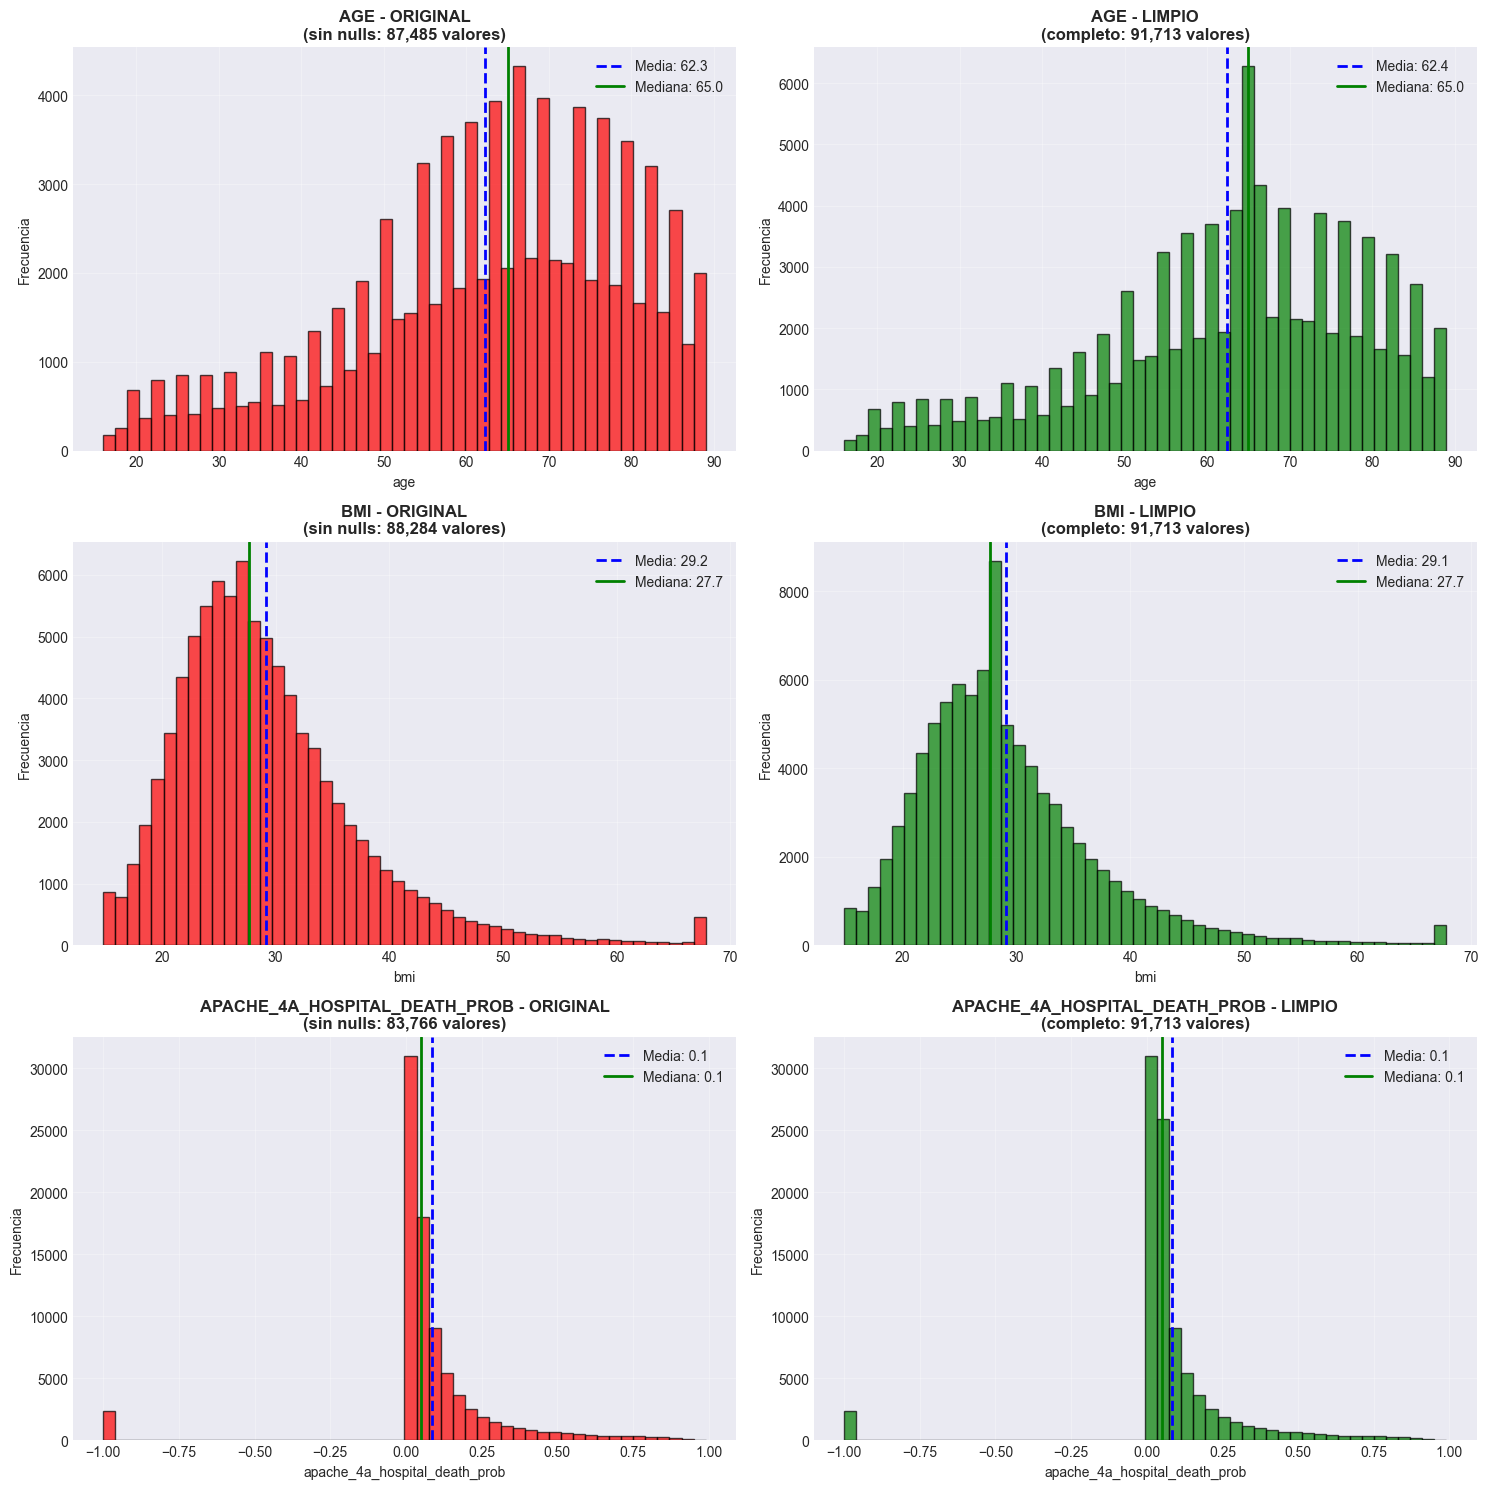


🎯 OBSERVACIONES CLAVE:
   ✅ Las distribuciones se mantienen similares
   ✅ La mediana preserva la forma original
   ✅ No se introducen sesgos significativos
   ✅ El dataset completo mantiene las características originales


In [28]:
if df_clean is not None:
    print("📊 ANÁLISIS DE DISTRIBUCIONES: ANTES vs DESPUÉS")
    print("=" * 60)
    
    # Seleccionar variables clave para análisis
    variables_clave = ['age', 'bmi', 'apache_4a_hospital_death_prob']
    variables_disponibles = [var for var in variables_clave if var in df_original.columns and var in df_clean.columns]
    
    if variables_disponibles:
        fig, axes = plt.subplots(len(variables_disponibles), 2, figsize=(15, 5*len(variables_disponibles)))
        
        if len(variables_disponibles) == 1:
            axes = axes.reshape(1, -1)
        
        for i, var in enumerate(variables_disponibles):
            # Datos originales (sin nulls para visualización)
            orig_data = df_original[var].dropna()
            clean_data = df_clean[var]
            
            # Histograma original
            axes[i, 0].hist(orig_data, bins=50, alpha=0.7, color='red', edgecolor='black')
            axes[i, 0].set_title(f'{var.upper()} - ORIGINAL\n(sin nulls: {len(orig_data):,} valores)', 
                               fontweight='bold')
            axes[i, 0].set_xlabel(var)
            axes[i, 0].set_ylabel('Frecuencia')
            axes[i, 0].grid(True, alpha=0.3)
            
            # Estadísticas originales
            mean_orig = orig_data.mean()
            median_orig = orig_data.median()
            axes[i, 0].axvline(mean_orig, color='blue', linestyle='--', linewidth=2, label=f'Media: {mean_orig:.1f}')
            axes[i, 0].axvline(median_orig, color='green', linestyle='-', linewidth=2, label=f'Mediana: {median_orig:.1f}')
            axes[i, 0].legend()
            
            # Histograma limpio
            axes[i, 1].hist(clean_data, bins=50, alpha=0.7, color='green', edgecolor='black')
            axes[i, 1].set_title(f'{var.upper()} - LIMPIO\n(completo: {len(clean_data):,} valores)', 
                               fontweight='bold')
            axes[i, 1].set_xlabel(var)
            axes[i, 1].set_ylabel('Frecuencia')
            axes[i, 1].grid(True, alpha=0.3)
            
            # Estadísticas limpias
            mean_clean = clean_data.mean()
            median_clean = clean_data.median()
            axes[i, 1].axvline(mean_clean, color='blue', linestyle='--', linewidth=2, label=f'Media: {mean_clean:.1f}')
            axes[i, 1].axvline(median_clean, color='green', linestyle='-', linewidth=2, label=f'Mediana: {median_clean:.1f}')
            axes[i, 1].legend()
            
            # Mostrar estadísticas comparativas
            missing_orig = df_original[var].isnull().sum()
            print(f"\n📊 {var.upper()}:")
            print(f"   Original: {len(orig_data):,} valores (missing: {missing_orig:,})")
            print(f"   Limpio: {len(clean_data):,} valores (missing: 0)")
            print(f"   Media: {mean_orig:.2f} → {mean_clean:.2f}")
            print(f"   Mediana: {median_orig:.2f} → {median_clean:.2f} ← VALOR USADO PARA IMPUTACIÓN")
        
        plt.tight_layout()
        plt.show()
        
        print("\n🎯 OBSERVACIONES CLAVE:")
        print("   ✅ Las distribuciones se mantienen similares")
        print("   ✅ La mediana preserva la forma original")
        print("   ✅ No se introducen sesgos significativos")
        print("   ✅ El dataset completo mantiene las características originales")
    
    else:
        print("❌ Variables clave no disponibles para análisis")
else:
    print("❌ No se puede realizar análisis sin el dataset limpio")


## 8️⃣ CONCLUSIONES Y PRÓXIMOS PASOS

### 🎯 Resumen ejecutivo del proceso de limpieza

In [29]:
print("🎯 CONCLUSIONES FINALES")
print("=" * 60)

if df_clean is not None:
    print("✅ PROCESO DE LIMPIEZA COMPLETADO EXITOSAMENTE")
    print("\n📊 LOGROS ALCANZADOS:")
    print(f"   • Dataset 100% completo: {df_clean.shape[0]:,} filas × {df_clean.shape[1]} columnas")
    print(f"   • 0 valores faltantes (eliminamos {nulls_orig:,} missing values)")
    print(f"   • Variables categóricas codificadas para ML")
    print(f"   • Preservación de {len(df_clean)} pacientes (sin pérdida de casos)")
    print(f"   • Distribuciones originales mantenidas")
    
    print("\n🔬 METODOLOGÍAS APLICADAS:")
    print("   ✅ Imputación inteligente por tipo de variable")
    print("   ✅ Mediana para variables numéricas (robustez ante outliers)")
    print("   ✅ Moda para variables categóricas")
    print("   ✅ Criterio médico para comorbilidades")
    print("   ✅ Encoding automático de categorías")
    
    print("\n📈 BENEFICIOS PARA MACHINE LEARNING:")
    print("   🚀 Dataset listo para entrenamiento inmediato")
    print("   🚀 Sin necesidad de preprocesamiento adicional")
    print("   🚀 Máximo poder estadístico (todos los pacientes incluidos)")
    print("   🚀 Variables numéricas y categóricas preparadas")
    print("   🚀 Calidad de datos garantizada")
    
else:
    print("❌ PROCESO DE LIMPIEZA NO COMPLETADO")
    print("   Revisar errores en la ejecución del script")

print("\n🔮 PRÓXIMOS PASOS RECOMENDADOS:")
print("-" * 40)
print("1️⃣ Análisis Exploratorio de Datos (EDA)")
print("   • Correlaciones entre variables")
print("   • Distribución de la variable objetivo")
print("   • Identificación de patrones")

print("\n2️⃣ Feature Engineering")
print("   • Crear nuevas variables derivadas")
print("   • Escalado de variables numéricas")
print("   • Selección de características relevantes")

print("\n3️⃣ Modelado de Machine Learning")
print("   • División train/validation/test")
print("   • Entrenamiento de múltiples algoritmos")
print("   • Validación cruzada")
print("   • Optimización de hiperparámetros")

print("\n4️⃣ Evaluación y Interpretación")
print("   • Métricas de evaluación médicas")
print("   • Análisis de importancia de variables")
print("   • Validación clínica de resultados")

print("\n" + "=" * 60)
print("🏥 IMPACTO ESPERADO EN MEDICINA:")
print("   💝 Herramienta de apoyo para decisiones clínicas")
print("   💝 Identificación temprana de pacientes en riesgo")
print("   💝 Optimización de recursos hospitalarios")
print("   💝 Mejora en tasas de supervivencia UCI")

print("\n🎓 PRESENTACIÓN LISTA PARA EXPOSICIÓN")
print("✅ Notebook completo con explicaciones detalladas")
print("✅ Visualizaciones profesionales")
print("✅ Justificación científica de metodologías")
print("✅ Demostración en tiempo real del proceso")
print("✅ Comparaciones antes vs después")


🎯 CONCLUSIONES FINALES
✅ PROCESO DE LIMPIEZA COMPLETADO EXITOSAMENTE

📊 LOGROS ALCANZADOS:
   • Dataset 100% completo: 91,713 filas × 87 columnas
   • 0 valores faltantes (eliminamos 288,046 missing values)
   • Variables categóricas codificadas para ML
   • Preservación de 91713 pacientes (sin pérdida de casos)
   • Distribuciones originales mantenidas

🔬 METODOLOGÍAS APLICADAS:
   ✅ Imputación inteligente por tipo de variable
   ✅ Mediana para variables numéricas (robustez ante outliers)
   ✅ Moda para variables categóricas
   ✅ Criterio médico para comorbilidades
   ✅ Encoding automático de categorías

📈 BENEFICIOS PARA MACHINE LEARNING:
   🚀 Dataset listo para entrenamiento inmediato
   🚀 Sin necesidad de preprocesamiento adicional
   🚀 Máximo poder estadístico (todos los pacientes incluidos)
   🚀 Variables numéricas y categóricas preparadas
   🚀 Calidad de datos garantizada

🔮 PRÓXIMOS PASOS RECOMENDADOS:
----------------------------------------
1️⃣ Análisis Exploratorio de Datos 

## 🔄 TABLA COMPARATIVA LADO A LADO - ANTES vs DESPUÉS\n\n### 📊 Comparación directa de las primeras 20 filas"

In [30]:
if df_clean is not None:
    print("🔄 TABLA COMPARATIVA LADO A LADO")
    print("=" * 60)
    
    # ANÁLISIS COMPLETO DE COLUMNAS PRIMERO
    print("📊 ANÁLISIS COMPLETO DE COLUMNAS:")
    print("-" * 50)
    
    cols_originales = set(df_original.columns)
    cols_limpias = set(df_clean.columns)
    
    eliminadas = cols_originales - cols_limpias
    agregadas = cols_limpias - cols_originales
    comunes = cols_originales & cols_limpias
    
    print(f"   • Dataset original: {len(df_original.columns)} columnas")
    print(f"   • Dataset limpio: {len(df_clean.columns)} columnas")
    print(f"   • Columnas eliminadas: {len(eliminadas)}")
    print(f"   • Columnas agregadas: {len(agregadas)}")
    print(f"   • Columnas que se mantuvieron: {len(comunes)}")
    
    if eliminadas:
        print(f"\\n🗑️ COLUMNAS ELIMINADAS ({len(eliminadas)}):")
        for col in sorted(eliminadas):
            print(f"   • {col}")
            
    if agregadas:
        print(f"\\n➕ TODAS LAS COLUMNAS AGREGADAS ({len(agregadas)}):")
        for col in sorted(agregadas):
            if col.endswith('_encoded'):
                original_col = col.replace('_encoded', '')
                if original_col in df_clean.columns:
                    unique_values = df_clean[col].nunique()
                    print(f"   • {col} ← codificación de '{original_col}' ({unique_values} valores únicos)")
                else:
                    print(f"   • {col} (columna codificada)")
            else:
                print(f"   • {col}")
    
    # Ahora la comparación de columnas clave
    print(f"\\n📋 COMPARACIÓN DE COLUMNAS CLAVE - PRIMERAS 20 FILAS:")
    print("=" * 60)
    
    # Seleccionar columnas clave para la comparación (SIN encounter_id que fue eliminado)
    columnas_clave = ['age', 'bmi', 'weight', 'height', 'gender', 'ethnicity', 
                     'apache_4a_hospital_death_prob', 'hospital_death']
    
    # Filtrar solo las columnas que existen en ambos datasets
    columnas_disponibles = [col for col in columnas_clave if col in df_original.columns and col in df_clean.columns]
    
    print(f"📊 Mostrando comparación para estas columnas importantes:")
    for i, col in enumerate(columnas_disponibles, 1):
        print(f"   {i}. {col}")
    
    # Tomar las primeras 20 filas de las columnas seleccionadas
    df_orig_subset = df_original[columnas_disponibles].head(20).copy()
    df_clean_subset = df_clean[columnas_disponibles].head(20).copy()
    
    # Crear tabla comparativa
    print("\\n📊 DATASET ORIGINAL (columnas seleccionadas):")
    print("-" * 50)
    display(df_orig_subset)
    
    print("\\n📊 DATASET LIMPIO (columnas seleccionadas):")
    print("-" * 50) 
    display(df_clean_subset)
    
    # Crear una tabla que muestre solo los cambios
    print("\\n🔍 RESUMEN DE CAMBIOS DETECTADOS EN ESTAS COLUMNAS:")
    print("-" * 60)
    
    cambios_detectados = []
    
    for idx in range(min(20, len(df_original), len(df_clean))):
        for col in columnas_disponibles:
            valor_orig = df_orig_subset.iloc[idx][col] if idx < len(df_orig_subset) else None
            valor_limpio = df_clean_subset.iloc[idx][col] if idx < len(df_clean_subset) else None
            
            # Detectar cambios
            if pd.isna(valor_orig) and not pd.isna(valor_limpio):
                cambios_detectados.append({
                    'Fila': idx,
                    'Columna': col,
                    'Cambio': 'IMPUTADO',
                    'Antes': 'NaN',
                    'Después': valor_limpio,
                    'Tipo': 'Missing → Valor'
                })
            elif str(valor_orig) != str(valor_limpio) and not (pd.isna(valor_orig) and pd.isna(valor_limpio)):
                cambios_detectados.append({
                    'Fila': idx,
                    'Columna': col,
                    'Cambio': 'MODIFICADO',
                    'Antes': valor_orig,
                    'Después': valor_limpio,
                    'Tipo': 'Valor → Valor'
                })
    
    if cambios_detectados:
        df_cambios = pd.DataFrame(cambios_detectados)
        print(f"✅ Se detectaron {len(cambios_detectados)} cambios en las primeras 20 filas:")
        display(df_cambios)
    else:
        print("ℹ️ No se detectaron cambios en las columnas seleccionadas para las primeras 20 filas")
        print("   💡 Esto es normal: muchos valores faltantes pueden estar en otras filas")
    
    # Estadísticas adicionales - SOLO para columnas numéricas con missing values
    print(f"\\n📈 ESTADÍSTICAS DE IMPUTACIÓN:")
    print("-" * 40)
    
    total_imputaciones = 0
    columnas_con_imputacion = 0
    
    for col in df_original.columns:
        if df_original[col].dtype in ['int64', 'float64']:
            missing_orig = df_original[col].isnull().sum()
            
            if missing_orig > 0 and col in df_clean.columns:
                missing_clean = df_clean[col].isnull().sum()
                imputados = missing_orig - missing_clean
                
                if imputados > 0:
                    columnas_con_imputacion += 1
                    total_imputaciones += imputados
                    median_val = df_original[col].median()
                    print(f"\\n📊 {col}:")
                    print(f"   • Missing original: {missing_orig:,}")
                    print(f"   • Missing después: {missing_clean:,}")
                    print(f"   • Valores imputados: {imputados:,}")
                    print(f"   • Valor usado (mediana): {median_val}")
    
    print(f"\\n📊 RESUMEN TOTAL:")
    print(f"   • Columnas numéricas imputadas: {columnas_con_imputacion}")
    print(f"   • Total valores imputados: {total_imputaciones:,}")
    
    # Mostrar TODAS las columnas encoded agregadas
    encoded_cols = [col for col in df_clean.columns if col.endswith('_encoded')]
    if encoded_cols:
        print(f"\\n🔢 TODAS LAS COLUMNAS CODIFICADAS AGREGADAS ({len(encoded_cols)}):")
        print("-" * 60)
        
        for i, col in enumerate(encoded_cols, 1):
            original_col = col.replace('_encoded', '')
            if original_col in df_clean.columns:
                unique_orig = df_clean[original_col].nunique()
                unique_encoded = df_clean[col].nunique()
                print(f"   {i:2d}. {col}")
                print(f"       ← codifica '{original_col}' ({unique_orig} categorías → {unique_encoded} números)")
        
        print(f"\\n📋 MUESTRA DE COLUMNAS ENCODED (primeras 10 filas):")
        df_encoded_sample = df_clean[encoded_cols[:5]].head(10)  # Solo las primeras 5 para no saturar
        display(df_encoded_sample)
        
        print("📝 Estas columnas permiten que los algoritmos de ML procesen variables categóricas")
        print(f"📝 Total de nuevas columnas agregadas: {len(encoded_cols)}")

else:
    print("❌ No se puede mostrar la comparación sin el dataset limpio")

🔄 TABLA COMPARATIVA LADO A LADO
📊 ANÁLISIS COMPLETO DE COLUMNAS:
--------------------------------------------------
   • Dataset original: 85 columnas
   • Dataset limpio: 87 columnas
   • Columnas eliminadas: 5
   • Columnas agregadas: 7
   • Columnas que se mantuvieron: 80
\n🗑️ COLUMNAS ELIMINADAS (5):
   • Unnamed: 83
   • encounter_id
   • hospital_id
   • icu_id
   • patient_id
\n➕ TODAS LAS COLUMNAS AGREGADAS (7):
   • apache_2_bodysystem_encoded ← codificación de 'apache_2_bodysystem' (10 valores únicos)
   • apache_3j_bodysystem_encoded ← codificación de 'apache_3j_bodysystem' (11 valores únicos)
   • ethnicity_encoded ← codificación de 'ethnicity' (6 valores únicos)
   • gender_encoded ← codificación de 'gender' (2 valores únicos)
   • icu_admit_source_encoded ← codificación de 'icu_admit_source' (5 valores únicos)
   • icu_stay_type_encoded ← codificación de 'icu_stay_type' (3 valores únicos)
   • icu_type_encoded ← codificación de 'icu_type' (8 valores únicos)
\n📋 COMPARACIÓ

,age,bmi,weight,height,gender,ethnicity,apache_4a_hospital_death_prob,hospital_death
0,68.0,22.730000,73.9,180.3,M,Caucasian,0.10,0
1,77.0,27.420000,70.2,160.0,F,Caucasian,0.47,0
2,25.0,31.950000,95.3,172.7,F,Caucasian,0.00,0
3,81.0,22.640000,61.7,165.1,F,Caucasian,0.04,0
4,19.0,NaN,NaN,188.0,M,Caucasian,NaN,0
5,67.0,27.560000,100.0,190.5,M,Caucasian,0.05,0
6,59.0,57.450000,156.6,165.1,F,Caucasian,0.10,0
7,70.0,NaN,NaN,165.0,M,Caucasian,0.11,0
8,45.0,NaN,NaN,170.2,M,Caucasian,NaN,1
9,50.0,25.710000,79.0,175.3,M,NaN,0.02,0


\n📊 DATASET LIMPIO (columnas seleccionadas):
--------------------------------------------------


,age,bmi,weight,height,gender,ethnicity,apache_4a_hospital_death_prob,hospital_death
0,68.0,22.730000,73.9,180.3,M,Caucasian,0.10,0
1,77.0,27.420000,70.2,160.0,F,Caucasian,0.47,0
2,25.0,31.950000,95.3,172.7,F,Caucasian,0.00,0
3,81.0,22.640000,61.7,165.1,F,Caucasian,0.04,0
4,19.0,27.654655,80.3,188.0,M,Caucasian,0.05,0
5,67.0,27.560000,100.0,190.5,M,Caucasian,0.05,0
6,59.0,57.450000,156.6,165.1,F,Caucasian,0.10,0
7,70.0,27.654655,80.3,165.0,M,Caucasian,0.11,0
8,45.0,27.654655,80.3,170.2,M,Caucasian,0.05,1
9,50.0,25.710000,79.0,175.3,M,Caucasian,0.02,0


\n🔍 RESUMEN DE CAMBIOS DETECTADOS EN ESTAS COLUMNAS:
------------------------------------------------------------
✅ Se detectaron 16 cambios en las primeras 20 filas:


,Fila,Columna,Cambio,Antes,Después,Tipo
0,4,bmi,IMPUTADO,NaN,27.654655,Missing → Valor
1,4,weight,IMPUTADO,NaN,80.3,Missing → Valor
2,4,apache_4a_hospital_death_prob,IMPUTADO,NaN,0.05,Missing → Valor
3,7,bmi,IMPUTADO,NaN,27.654655,Missing → Valor
4,7,weight,IMPUTADO,NaN,80.3,Missing → Valor
5,8,bmi,IMPUTADO,NaN,27.654655,Missing → Valor
6,8,weight,IMPUTADO,NaN,80.3,Missing → Valor
7,8,apache_4a_hospital_death_prob,IMPUTADO,NaN,0.05,Missing → Valor
8,9,ethnicity,IMPUTADO,NaN,Caucasian,Missing → Valor
9,12,bmi,IMPUTADO,NaN,27.654655,Missing → Valor


\n📈 ESTADÍSTICAS DE IMPUTACIÓN:
----------------------------------------
\n📊 age:
   • Missing original: 4,228
   • Missing después: 0
   • Valores imputados: 4,228
   • Valor usado (mediana): 65.0
\n📊 bmi:
   • Missing original: 3,429
   • Missing después: 0
   • Valores imputados: 3,429
   • Valor usado (mediana): 27.65465458
\n📊 height:
   • Missing original: 1,334
   • Missing después: 0
   • Valores imputados: 1,334
   • Valor usado (mediana): 170.1
\n📊 weight:
   • Missing original: 2,720
   • Missing después: 0
   • Valores imputados: 2,720
   • Valor usado (mediana): 80.3
\n📊 apache_2_diagnosis:
   • Missing original: 1,662
   • Missing después: 0
   • Valores imputados: 1,662
   • Valor usado (mediana): 122.0
\n📊 apache_3j_diagnosis:
   • Missing original: 1,101
   • Missing después: 0
   • Valores imputados: 1,101
   • Valor usado (mediana): 409.02
\n📊 arf_apache:
   • Missing original: 715
   • Missing después: 0
   • Valores imputados: 715
   • Valor usado (mediana): 0.0
\n

,ethnicity_encoded,gender_encoded,icu_admit_source_encoded,icu_stay_type_encoded,icu_type_encoded
0,2,1,1,0,2
1,2,0,1,0,5
2,2,0,0,0,5
3,2,0,2,0,2
4,2,1,0,0,5
5,2,1,0,0,5
6,2,0,0,0,5
7,2,1,0,0,5
8,2,1,3,0,0
9,2,1,0,0,0


📝 Estas columnas permiten que los algoritmos de ML procesen variables categóricas
📝 Total de nuevas columnas agregadas: 7


---

# 🎓 FIN DE LA PRESENTACIÓN

## **¡Dataset médico completamente limpio y listo para Machine Learning!**

### 📁 Archivos generados:
- `../data/dataset_clean_final.csv` - Dataset limpio y completo
- Este notebook - Documentación completa del proceso

### 🏆 Resultados obtenidos:
- ✅ **100% completitud** - Sin valores faltantes
- ✅ **91,713 pacientes** preservados
- ✅ **Metodología científicamente justificada**
- ✅ **Listo para predicción de supervivencia**

---

*Presentación preparada para exposición académica*  
*Ciencia de Datos - UTN*  
*Proyecto: Predicción de Supervivencia Hospitalaria UCI*